# Notebook for designing DNA nanostars

This code has been cleaned up a bit from "DNA-Liquid-Sequence-Design-With-ViennaRNA-ARCHIVAL.ipynb", which was frozen on Dec 21, 2023.  That version has various explorations and stream-of-consciousness discussion that had been removed from this version.

Thie current code ought to be suffficient to design 16 reasonably orthogonal nanostars.  

# Installation Vienna RNA package

With a new Google Colab connection to a virtual machine, you must first install Vienna RNA, which takes just a few minutes via the first three cells.  Thereafter, until you get disconnected and assigned to a new virtual machine, you can restart the kernel as many times as you want and just do the "import" commants with no need to re-install.

Vienna RNA documentation is here: https://www.tbi.univie.ac.at/RNA/ViennaRNA/doc/html/index.html

In [1]:
# Run this once. It will automatically restart the kernel.  Should take under a minute.
# No need to do it if conda is already installed, as per the test below in the next cell.
!pip install -q condacolab
import condacolab
condacolab.install()

RuntimeError: This module must ONLY run as part of a Colab notebook!

In [ ]:
# probably this is v23.1.0
!conda --version

conda 23.1.0


In [ ]:
# After the restart, do this to install ViennaRNA on your virtual machine, if it is not there already.
!conda install -c bioconda viennarna

Solving environment: | / - \ | / - \ | / - \ | / - \ done


==> WARNING: A newer version of conda exists. <==
  current version: 23.1.0
  latest version: 23.11.0

Please update conda by running

    $ conda update -n base -c conda-forge conda

Or to minimize the number of packages updated during conda update use

     conda install conda=23.11.0



## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - viennarna


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2023.11.17 |       hbcca054_0         151 KB  conda-forge
    certifi-2023.11.17         |     pyhd8ed1ab_0         155 KB  conda-forge
    libxcrypt-4.4.36           |       hd590300_1          98 KB  conda-forge
    openssl-3.2.0              |       hd590300_1         2.7 MB  conda-forge
    perl-5.32.1                | 7_hd590300_perl5        12.7 

Once Vienna RNA is installed, new runtime kernels can start here at the import statement...

In [ ]:
# now let's import everything we'll need, and make sure ViennaRNA is at least v2.6.4
from IPython import display
from matplotlib import pyplot as plt
import numpy as np
import random, copy, time
from functools import lru_cache
import ViennaRNA
from ViennaRNA import RNA
RNA.__version__

'2.6.4'

# Testing ViennaRNA

This section can be skipped.  FYI only.

In [ ]:
# Until another model is loaded into ViennaRNA's global parameter database, RNA is the default.  So the last one to be loaded will be used.
RNA.params_load_RNA_Turner2004()
RNA.params_load_DNA_Mathews2004()

# The RNA sequences separated by an & for multistranded complexes.
# I don't think ViennaRNA will include symmetry corrections for dimers, i.e. it uses a distinguishable-strands ensemble.
seq = "GAGUAGUGGAACCAGGCUAUGUUUGUGACUCGCAGACUAACA&UGUUAGUCUAAAC"

# create a new model details structure
md = RNA.md()

# change temperature and dangle model
md.temperature = 20.0 # 20 Deg Celcius

# create a fold compound
fc = RNA.fold_compound(seq, md)

# predict Minmum Free Energy and corresponding secondary structure
(ss, mfe) = fc.mfe()

# print sequence, structure and MFE
amp=seq.find('&')
print("{}\n{} [ {:6.2f} ]\n{}".format(seq, ss, mfe, ss[:amp]+'&'+ss[amp:]))

# predict Minmum Free Energy and corresponding secondary structure
(pp, pf) = fc.pf()

# print sequence, pair probs and partition function
print("{}\n{} [ {:6.2f} ]\n{}".format(seq, pp, pf, pp[:amp]+'&'+pp[amp:]))

GAGUAGUGGAACCAGGCUAUGUUUGUGACUCGCAGACUAACA&UGUUAGUCUAAAC
((((....((((........))))...))))..((((((((())))))))).... [ -23.77 ]
((((....((((........))))...))))..(((((((((&)))))))))....
GAGUAGUGGAACCAGGCUAUGUUUGUGACUCGCAGACUAACA&UGUUAGUCUAAAC
((((.,,,({{(,,,,,...)))),..))))..(((((((({})))))))).... [ -24.62 ]
((((.,,,({{(,,,,,...)))),..))))..(((((((({&}))))))))....


Let's try ChatGPT's suggestion for how to look at secondary structures visually.

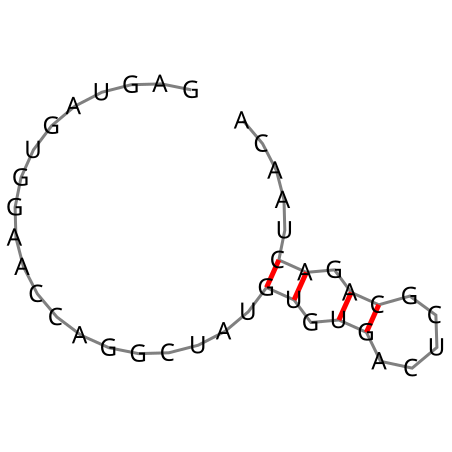

In [ ]:
seq = "GAGTAGTGGAACCAGGCTATGTGTGACTCGCAGACTAACA"
seq = "GAGUAGUGGAACCAGGCUAUGUGUGACUCGCAGACUAACA"
ss, mfe = RNA.fold(seq) # uses recently-loaded DNA or RNA params, RNA.cvar.temperature (deg C), .salt (M Na), .dangles (0 off, 1 some, 2 all, 3 coax)
success=RNA.svg_rna_plot(seq, ss, "rna_structure.svg")
display.SVG(filename='rna_structure.svg')

# Evaluate the matrix of interactions and optimize for target interactions

Definition cells here must be executed.  There are just four cell of relevance; the other stuff is just examples and tests, and can be ignored.

In [ ]:
def random_strands(N,M,alpha='ACGT'):
  strands=[ ''.join([ random.choice(alpha) for i in range(M) ]) for j in range(N) ]
  return(strands)

In [ ]:
# default settings. the rest of the code will use this implicitly, unless it's explicitly set elsewhere.
RNA.cvar.temperature=20  # room temperature
RNA.cvar.salt=1          # standard value, close enough
RNA.cvar.dangles=2       # necessary for pf calcs
RNA.params_load_DNA_Mathews2004()

# because of memoization, don't change temperature etc anywhere else if you want binding_pair() to return the correct value

# memoize binding calculations, so repeated perturbations of systems with common strands aren't needlessly redundant
@lru_cache(maxsize=1000000)
def binding_pair(strandpair):
  md = RNA.md()
  #md.temperature=20
  #md.salt=1
  #md.dangles=2
  fc = RNA.fold_compound(strandpair[0]+'&'+strandpair[1], md)
  # partition function is slower but presumably better than mfe for our purposes
  (pp12, pf12) = fc.pf()
  # important for strands longer than 8 or so: subtract the single-stranded pf for each strand.
  fc = RNA.fold_compound(strandpair[0], md)
  (pp1, pf1) = fc.pf()
  fc = RNA.fold_compound(strandpair[1], md)
  (pp2, pf2) = fc.pf()
  return pf12-pf1-pf2

def binding_matrix(strands):
  """compute the matrix of binding dG (using whatever temperature and material has been loaded, default as DNA at 20 C)"""
  N=len(strands)
  M=len(strands[0])
  dG=[[0 for i in range(N)] for j in range(N)]
  for i in range(N):
    for j in range(N):
      dG[i][j]=binding_pair( (strands[i],strands[j]) )
  return dG

# we will use a simpler, faster estimate in cases where the details matter less, and strands are longer -- i.e. the arm domains.
@lru_cache(maxsize=1000000)
def binding_pair_mfe(strandpair):
  md = RNA.md()
  #md.temperature=20
  #md.salt=1
  #md.dangles=2
  fc = RNA.fold_compound(strandpair[0]+'&'+strandpair[1], md)
  (ss12, mfe12) = fc.mfe()
  return mfe12

def binding_matrix_mfe(strands):
  """compute the basic mfe matrix of binding dG (using whatever temperature and material has been loaded, default as DNA at 20 C)"""
  N=len(strands)
  M=len(strands[0])
  dG=[[0 for i in range(N)] for j in range(N)]
  for i in range(N):
    for j in range(N):
      dG[i][j]=binding_pair_mfe( (strands[i],strands[j]) )
  return dG

In [ ]:
strands=random_strands(3,42)

In [ ]:
test=binding_matrix(strands)
print(test)

[[-4.897403717041016, -5.64329195022583, -4.874835014343262], [-5.6433491706848145, -4.0205888748168945, -5.462554454803467], [-4.874285697937012, -5.462684154510498, -7.066036224365234]]


In [ ]:
# this is a destructive operation: the "strands" variable will be changed
def perturb_strands(strands,num,alpha='ACGT'):
  for n in range(num):
    i=random.randint(0,len(strands)-1)
    j=random.randint(0,len(strands[i])-1)
    bases=list(strands[i])
    bases[j]=random.choice(alpha)
    strands[i]=''.join(bases)

In [ ]:
strands

['CAATTACATCAAAGACAGAATCCCTGCGAAAGGCTGCCAGGG',
 'AACTTTCTCAATCATTCTCTGACGTTCTGATTGGTTCCAGCC',
 'TGCACTCTTATAAGTTCATCGGATGGGGACCATAGTTGTTAT']

In [ ]:
perturb_strands(strands,10)

In [ ]:
strands

['TTTACTCACACGTGTACCATACTGGTGGTCCTTACATCCGAC',
 'AGACGTAACGTTCACGTGAAAGCCCCCCGGAATGGGTTACTC',
 'TCTAAAGACGTTCTGCCTGATAATAACCAAGTTGTCTACTTT']

In [ ]:
# reduce the mean-squared error for the pairwise energy predictions
def matrix_score_strands(strands,dGtarget):
  N=len(strands)
  dG=binding_matrix(strands)
  err = [ (dG[i][j]-dGtarget[i][j])**2 for i in range(N) for j in range(N) ]
  return sum(err)

# to strongly prohibit certain subsequences or weak/strong patterns or pyrimidine/puring patterns
def avoid_constraint(string,avoid):
  ppstring=string.translate(str.maketrans({'A':'R','G':'R','T':'P','C':'P'}))
  wsstring=string.translate(str.maketrans({'A':'W','G':'S','T':'W','C':'S'}))
  return any([s in string or s in ppstring or s in wsstring for s in avoid])

def minimize_matrix_imperfection(strands,steps,mutations,dGtarget,alpha='ACGT',avoid=[]):
  score=matrix_score_strands(strands,dGtarget)
  score *= 1 if len(avoid)==0 else 1+sum([avoid_constraint(strand,avoid) for strand in strands])
  score *= 1 if len(set(strands))==len(strands) else 1+len(strands)-len(set(strands)) # must be unique!
  for step in range(steps):
    newstrands=copy.deepcopy(strands)
    perturb_strands(newstrands,mutations,alpha=alpha)
    newscore = matrix_score_strands(newstrands,dGtarget)
    newscore *= 1 if len(avoid)==0 else 1+sum([avoid_constraint(strand,avoid) for strand in newstrands])
    newscore *= 1 if len(set(newstrands))==len(newstrands) else 1+len(newstrands)-len(set(newstrands))
    if newscore<score:
      score=newscore
      strands=newstrands
      print(f'step {step}: score={score}')
  return strands

In [ ]:
# test basic functionality
strands=random_strands(3,10) # three 10-mer sticky ends
target=[[-5,-10,0],[-10,0,0],[0,0,-3]]
strands=minimize_matrix_imperfection(strands,1000,3,target)

step 0: score=206.54868730595223
step 1: score=193.93291492090532
step 2: score=145.00573236681583
step 3: score=138.34847204311026
step 4: score=117.05715704439045
step 10: score=116.83750735811742
step 12: score=114.4157992854165
step 22: score=114.40516278889031
step 24: score=113.20399187872067
step 29: score=81.5324648427671
step 40: score=71.97988582823565
step 44: score=70.16174821212914
step 59: score=68.6879971540634
step 103: score=50.74351186979561
step 112: score=38.477742215795615
step 230: score=36.50558971693547
step 254: score=36.28078499146849
step 282: score=34.97981263117937
step 285: score=32.679787142262164
step 326: score=23.775068644301697
step 614: score=23.47273611939208
step 650: score=22.72223224575242
step 658: score=21.95501904687557
step 677: score=17.399636219528162
step 818: score=5.373692820483257


In [ ]:
strands

['CCACCGCTGG', 'TGCGGTGGCA', 'GTTAAAAACA']

In [ ]:
# test prohibition
strands=random_strands(3,10) # three 10-mer sticky ends
target=[[-5,-10,0],[-10,0,0],[0,0,-3]]
strands=minimize_matrix_imperfection(strands,2000,3,target,avoid=['SSSS','WWWWWW'])

step 1: score=133.10424742605613
step 11: score=120.53278330674425
step 12: score=95.34384302167958
step 25: score=92.5024821761655
step 33: score=81.0052578035412
step 39: score=65.1559109696728
step 53: score=55.59031013359914
step 66: score=50.94967535352539
step 73: score=45.83338166987446
step 114: score=41.053353376666834
step 118: score=39.02687666302458
step 156: score=36.23883721015031
step 243: score=34.89456088584144
step 250: score=33.39551149155133
step 437: score=31.77861210744389
step 501: score=26.076266059018735
step 651: score=24.187100288564764
step 959: score=23.780878479580196
step 1023: score=20.883119347038566
step 1024: score=20.796491499960887
step 1069: score=20.72191428866389
step 1243: score=20.138512529899096
step 1409: score=19.72477227509028
step 1849: score=19.685104147494563


In [ ]:
strands

['GGGAAATCCT', 'TTTGGATTTC', 'TACATAGTGT']

In [ ]:
binding_matrix(strands)

[[-4.185483694076538, -9.292738646268845, -0.9764479398727417],
 [-9.292738646268845, -2.7351052165031433, -2.0672291219234467],
 [-0.9764479398727417, -2.067039340734482, -3.295703411102295]]

# Analysis and design of DNA nanostars with palindromic sticky ends

This contains the first version of my scorecard and design code.  Again, all five function definition cells ought to be executed.

A DNA nanostar system will be a list of strand sequences, 4 per nanostar, where each has format
* domain-AA-domain-A-toe

where we assume that the set of first domains equals the complement of set of second domains. The spacer 'A' could be replaced by another value, such as 'T', if you wish.

In [ ]:
np.array(binding_matrix(['ACCTAGG','AGAGCTC'])) # for Olivia's sticky ends in the nanostars below

array([[ -9.55344316,  -3.33162666],
       [ -3.33162666, -10.01740531]])

In [ ]:
olivia_nanostars=[
    # nanostar 4-ns20-6SE23-v1
    'CTCCGATCGGGATCGACGGGAACGTGGTCCAATGTGGAAACGACCTAGG',
    'CGTTTCCACATTGGACCACGAACTGAGGCCGTTCATATGGTAACCTAGG',
    'TACCATATGAACGGCCTCAGAACCTGAATCTGCCAATTACGAACCTAGG',
    'TCGTAATTGGCAGATTCAGGAACCCGTCGATCCCGATCGGAGACCTAGG',
    # nanostar 4-ns20-6SE34-v1
    'CATCCGCTCATCTTGGCAGCAAGGATAACCGGTGCGACACGGAGAGCTC',
    'CCGTGTCGCACCGGTTATCCAAGGCCTGGTCACTCCCAGTGGAGAGCTC',
    'CCACTGGGAGTGACCAGGCCAACGCCAGAGTGATAGGTCACGAGAGCTC',
    'CGTGACCTATCACTCTGGCGAAGCTGCCAAGATGAGCGGATGAGAGCTC'
]

# target binding matrix for Vienna MFE at 20 C to match Olivia's average sticky end energy
olivia_targetG=[[-9.75,-3.3],[-3.3,-9.75]]

In [ ]:
# yancheng's 4 nanostar sticky ends, including the A spacer
yanchengGdesigned=np.array(binding_matrix(['AACATGT','ATTCGAA','AAAGCTT','AGGATCC']))
yanchengGdesigned

array([[-8.32481183, -2.57123315, -2.53327782, -2.62292696],
       [-2.57123315, -8.26888976, -2.33082442, -2.93567919],
       [-2.53327782, -2.33074122, -8.02065158, -2.68543571],
       [-2.62292696, -2.93565701, -2.68524379, -9.71810639]])

Surprise!  Although when evaluated at 37 C, as per when they were designed, sticky end 4 is only about 0.9 kcal/mol stronger than the others, at 20 C as computed here, the prediction is 1.7 kcal/mol stronger than the weakest one.

Also note that these droplets, experimentally, we quite effectively orthogonal and did not stick to each other much, so the off-diagonal -2.5 kcal/mol is likely not significant, e.g. as if ViennaRNA does not add an initiation penalty to the energy for multistranded complexes.

In [ ]:
# yancheng's 4 nanostar sticky ends, including the A spacer and example hairpin stems from 1st arm
np.array(binding_matrix(['GTGTCACTTTGTGACACAACATGT','CGATGCATTTTGCATCGATTCGAA','ATGCTTGTTTCAAGCATAAAGCTT','ATTACGCTTTGCGTAATAGGATCC']))

array([[-8.31925964, -2.61164761, -2.85209227, -2.69934654],
       [-2.61164761, -8.26388741, -2.54105806, -2.98844051],
       [-2.85209227, -2.54100466, -7.92342472, -3.02037382],
       [-2.69934654, -2.98834896, -3.02000189, -9.70387459]])

In [ ]:
# This was ordered in November 2023
superopti4nanostars20231115=[ # two-stage design by Erik; better sticky ends; trunc protection
    # SOT1
    'TACTGTGATCGACGCTCTTGAATACTCTAGGCGATGTGACACAACATGT',
    'GTGTCACATCGCCTAGAGTAAAGGCAGTACCTTATGACTCATAACATGT',
    'ATGAGTCATAAGGTACTGCCAATGGTTGACACCGACAGTAGTAACATGT',
    'ACTACTGTCGGTGTCAACCAAACAAGAGCGTCGATCACAGTAAACATGT',
    # SOT2
    'AGTCAGACCATGGGACATCGAATGTGCGAGACACTTGCATCGATTCGAA',
    'CGATGCAAGTGTCTCGCACAAATGTACGAAGTCTTGCCAGATATTCGAA',
    'ATCTGGCAAGACTTCGTACAAATTGACCTCGAACTGCTAGTAATTCGAA',
    'TACTAGCAGTTCGAGGTCAAAACGATGTCCCATGGTCTGACTATTCGAA',
    # SOT3
    'GAAATCTAGCCGTTATCAGCAAGTCATGTCTACGGCAAGCATAAAGCTT',
    'ATGCTTGCCGTAGACATGACAAAAGTTACCTACAACTAGTGCAAAGCTT',
    'GCACTAGTTGTAGGTAACTTAACATACGATTGTGGGCACGTAAAAGCTT',
    'TACGTGCCCACAATCGTATGAAGCTGATAACGGCTAGATTTCAAAGCTT',
    # SOT4
    'ACTAATGGACCCTGCGTTGCAACCGAGTCCACCGTGCGTAATAGGATCC',
    'ATTACGCACGGTGGACTCGGAACCAAGTAGTGACCGTCTCTAAGGATCC',
    'TAGAGACGGTCACTACTTGGAACTGATGACGAATGATTGGCCAGGATCC',
    'GGCCAATCATTCGTCATCAGAAGCAACGCAGGGTCCATTAGTAGGATCC'
]

# target binding matrix for a 4-nanostar system that would match the November design but make it more uniform
yancheng_targetG=[[-8.5,-2.5,-2.5,-2.5],[-2.5,-8.5,-2.5,-2.5],[-2.5,-2.5,-8.5,-2.5],[-2.5,-2.5,-2.5,-8.5]]

Now we will define simple combinatorial scores. These aren't as expensive as mfe and pf, but there is still a speed up to be had by caching.  Unfortunately, not for SSM because it is a system-wide score rather than a per-strand score.

In [ ]:
@lru_cache(maxsize=100000)
def repeat_vector(string,maxrep=6):
  '''Probably the slowest way to get counts[n] = number of times the same character is repeated n times in a row.'''
  counts=[0 for n in range(maxrep+1)]
  slen=len(string)
  i=0
  while i<slen:
    rep=1
    while i+1<slen and string[i]==string[i+1]:
      rep+=1
      i+=1
    rep=min(maxrep,rep)
    counts[rep]+=1
    i+=1
  return counts

@lru_cache(maxsize=100000)
def repeat_vector_PP(string,maxrep=6):
  '''like repeat_vector, but also includes purine / pyramidine repeats'''
  ppstring=string.translate(str.maketrans({'A':'R','G':'R','T':'P','C':'P'}))
  return list(np.array(repeat_vector(string))+np.array(repeat_vector(ppstring)))

@lru_cache(maxsize=100000)
def repeat_vector_PPWS(string,maxrep=6):
  '''like repeat_vector, but also includes purine / pyramidine repeats and Weak/Strong repeats'''
  ppstring=string.translate(str.maketrans({'A':'R','G':'R','T':'P','C':'P'}))
  wsstring=string.translate(str.maketrans({'A':'W','G':'S','T':'W','C':'S'}))
  return list(np.array(repeat_vector(string))+np.array(repeat_vector(ppstring))+np.array(repeat_vector(wsstring)))

def system_SSM(strings,minlen=3,maxlen=10):
  present=set()
  counts=[0 for n in range(maxlen+1)]
  for string in strings:
    for slen in range(minlen,maxlen+1):
      for pos in range(0,len(string)-slen+1):
        sub=string[pos:pos+slen]
        if sub in present:
          counts[slen]+=1
        else:
          present.add(sub)
  return counts

def nanostar_stats(nanostars,spacer='A',domlen=20,stickylen=6,dopairwise=True):
  nanostarso=[]; # reorder such that antisense domains appear in same order as sense
  while len(nanostarso)<len(nanostars):
    nanostarso.append(nanostars[len(nanostarso)+4*(len(nanostarso)%4==0)-1])
  domains=[ strand[0:domlen] for strand in nanostars ]+[ strand[domlen+2:2*domlen+2] for strand in nanostarso ]
  stickies=[ strand[-stickylen:] for strand in nanostars[::4] ]
  if dopairwise:
    stickypurebinding=binding_matrix(stickies) # to encourage alignment, don't include the space for dangle energy
    stickybadbinding=binding_matrix([ spacer+sticky for sticky in stickies ]) # allow for more possible misalignments
    stickytruncation=binding_matrix([ strand[-2*stickylen:] for strand in nanostars ])
    dombinding=binding_matrix_mfe(domains)
  else: # in case we only want to evaluate the fast combinatorial stats, e.g. for quick rough scoring
    all0s=[[0 for i in stickies] for j in stickies]
    all0n=[[0 for i in nanostars] for j in nanostars]
    all0d=[[0 for i in domains] for j in domains]
    (stickypurebinding,stickybadbinding,stickytruncation,dombinding)=(all0s,all0s,all0n,all0d)
  domatcg=[ [ sum([ base==ref for base in dom])/domlen for ref in 'ATCG' ] for dom in domains ]
  strandrepeat=[ repeat_vector_PPWS(strand) for strand in nanostars]
  systemSSM=system_SSM(nanostars)
  return (stickypurebinding,stickybadbinding,stickytruncation,dombinding,domatcg,strandrepeat,systemSSM)


In [ ]:
repeat_vector_PPWS('AATTTTATTTATTGTGGAGG')

[0, 12, 8, 2, 2, 1, 1]

In [ ]:
system_SSM(['ATGCTTCGT','TCGGCGCGA','ATGCAATCGTCGGC'])

[0, 0, 0, 9, 4, 1, 0, 0, 0, 0, 0]

In [ ]:
def show_nanostar_stats(targetG,nanostars,spacer='A',domlen=20,stickylen=6):
  S=len(nanostars)
  N=S//4;
  (sb,sbb,stn,db,atcg,reps,ssm)=nanostar_stats(nanostars,spacer=spacer,domlen=domlen,stickylen=stickylen)

  # sticky end binding (with spacer)
  plt.matshow(sbb)
  plt.colorbar()
  tGs = [G for line in targetG for G in line]
  rGs = [G for line in sb for G in line]
  rbGs = [G for line in sbb for G in line]
  min_mean_max=[]
  print('\ntarget G :    min      mean      max     RMS deviation from target    min/max deviation with spacer')
  for G in set(tGs):
    triples=list(filter(lambda trg: trg[0]==G,zip(tGs,rGs,rbGs)))
    vals=np.array([v[2] for v in triples])
    diffs=np.array([v[1]-v[2] for v in triples])
    print(f'   {G:5.1f} :  {np.min(vals):5.1f}    {np.mean(vals):5.1f}     {np.max(vals):5.1f}           {np.mean((vals-G)**2)**0.5:5.1f}                          {min(diffs):4.2f}/{max(diffs):4.2f}')

  # domain binding
  plt.matshow(db)
  plt.colorbar()
  tGs = [G for line in [[-1.5*domlen if abs(i-j)==S else 0 for i in range(2*S)] for j in range(2*S)] for G in line]
  rGs = [G for line in db for G in line]
  min_mean_max=[]
  print('\ndomain G :    min      mean      max     standard deviation from mean')
  for G in set(tGs):
    pairs=list(filter(lambda trg: trg[0]==G,zip(tGs,rGs)))
    vals=np.array([v[1] for v in pairs])
    print(f'   {G:5.1f} :  {np.min(vals):5.1f}    {np.mean(vals):5.1f}     {np.max(vals):5.1f}           {np.std(vals):5.1f}')

  atcglist=np.array([val for freq in atcg for val in freq])
  print(f'\nworst domain atcg deviation from 0.25, and std: {np.max(np.abs(atcglist-0.25)):4.2f}, {np.std(atcglist):4.2f}')

  repeats=np.sum(np.array(reps),axis=0)
  print(f'\nnumber of length-n repeats for     n =    3    4    5    6')
  print(f'                                      {repeats[3]:5d}{repeats[4]:5d}{repeats[5]:5d}{repeats[6]:5d}')

  print(f'\nnumber of length-n SSM clashes for n =    3    4    5    6    7    8    9    10')
  print(f'                                      {ssm[3]:5d}{ssm[4]:5d}{ssm[5]:5d}{ssm[6]:5d}{ssm[7]:5d}{ssm[8]:5d}{ssm[9]:5d}{ssm[10]:5d}')

  tGs=dict()
  for i in range(S):
    for j in range(S):
      tG = targetG[i//4][j//4]
      if tG in tGs:
        tGs[tG]=tGs[tG]+[stn[i][j]-sbb[i//4][j//4]]
      else:
        tGs[tG]=[stn[i][j]-sbb[i//4][j//4]]
  print(f'\nsticky-end / stem truncation robustness per target G :   min    mean    max    std')
  for tG in tGs:
    print(f'                                               {tG:5.1f} : {np.min(tGs[tG]):5.1f}   {np.mean(tGs[tG]):5.1f}  {np.max(tGs[tG]):5.1f}  {np.std(tGs[tG]):5.1f}')

  return (sb,sbb,stn,db,atcg,reps,ssm)


target G :    min      mean      max     RMS deviation from target    min/max deviation with spacer
    -3.3 :   -3.3     -3.3      -3.3             0.0                          0.08/0.08
    -9.8 :  -10.0     -9.8      -9.6             0.2                          1.93/2.26

domain G :    min      mean      max     standard deviation from mean
     0.0 :  -15.1    -10.0      -5.0             1.8
   -30.0 :  -36.1    -34.4     -31.6             1.6

worst domain atcg deviation from 0.25, and std: 0.15, 0.08

number of length-n repeats for     n =    3    4    5    6
                                         62   28   14    2

number of length-n SSM clashes for n =    3    4    5    6    7    8    9    10
                                        312  186   76   36   16    7    1    0

sticky-end / stem truncation robustness per target G :   min    mean    max    std
                                                -9.8 :   0.1     0.7    1.6    0.4
                                        

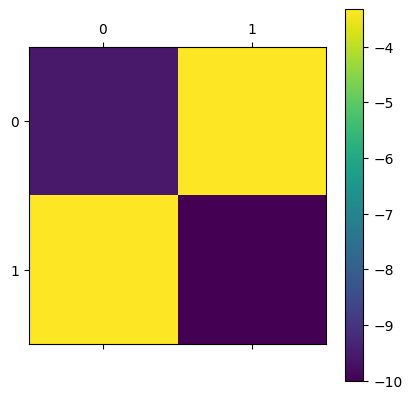

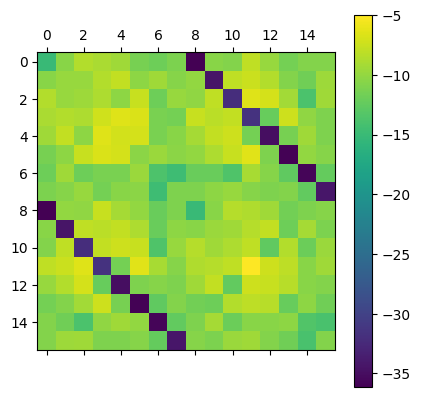

In [ ]:
(sb,sbb,stn,db,atcg,reps,ssm)=show_nanostar_stats(olivia_targetG,olivia_nanostars)


target G :    min      mean      max     RMS deviation from target    min/max deviation with spacer
    -8.5 :   -9.7     -8.6      -8.0             0.7                          0.79/1.92
    -2.5 :   -2.9     -2.6      -2.3             0.2                          -0.06/0.23

domain G :    min      mean      max     standard deviation from mean
     0.0 :  -13.5     -8.3      -4.3             1.7
   -30.0 :  -35.2    -32.5     -29.5             1.5

worst domain atcg deviation from 0.25, and std: 0.10, 0.04

number of length-n repeats for     n =    3    4    5    6
                                        114   59   15    0

number of length-n SSM clashes for n =    3    4    5    6    7    8    9    10
                                        688  502  209   52   16    4    0    0

sticky-end / stem truncation robustness per target G :   min    mean    max    std
                                                -8.5 :  -0.1     1.2    5.2    1.0
                                       

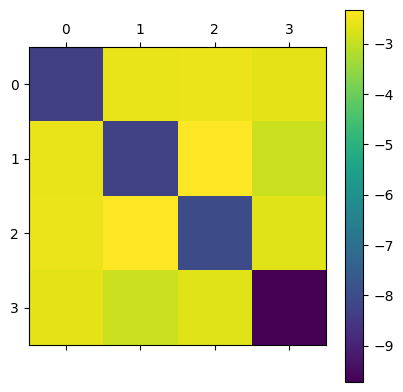

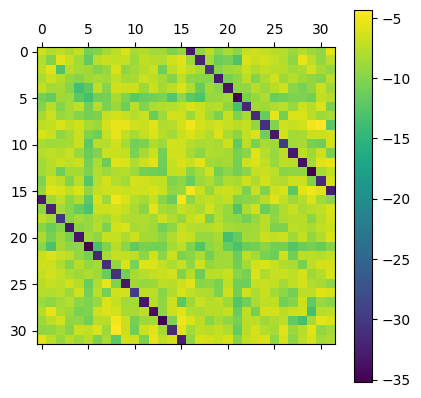

In [ ]:
(sb,sbb,stn,db,atcg,reps,ssm)=show_nanostar_stats(yancheng_targetG,superopti4nanostars20231115)

In [ ]:
# for historical reasons, this score still has a sticky-end component, but optimizing it didn't lead to good results, so it will be ignored by the two-stage designer.
def nanostar_score(nanostars,targetGsticky,
                   spacer='A',domlen=20,stickylen=6,
                   dompow=3.0,ssmpow=4.0,atcgpow=2.0,repcost=[0,0,0,1,3,30,100],w=[50,0.1,10,1,0.001,1]):
  dopairwise=(w[0]+w[1]+w[5]>0)
  (sb,sbb,stn,db,atcg,reps,ssm)=nanostar_stats(nanostars,spacer=spacer,domlen=domlen,stickylen=stickylen,dopairwise=dopairwise)
  N=len(sb)           # number of nanostars
  S=len(nanostars)    # number of strands = 4 * number of nanostars = number of sense & antisense domains / 4
  L=len(nanostars[0]) # strand length
  # average binding dG difference from target
  stickyscore = sum([ abs(sbb[i][j]-targetGsticky[i][j]) for i in range(N) for j in range(N) ])/(N*N) + \
                np.var([ sb[i][j]-sbb[i][j] for i in range(N) for j in range(N) ])
  # average binding dG for non-complementary domains, cubic weighted to emphasize worst ones
  domscore = sum([ 0 if abs(i-j)==S else abs(db[i][j])**dompow for i in range(2*S) for j in range(2*S) ])/(4*S*S-2*S)
  atcgscore = sum([ abs(v-0.25)**atcgpow for fs in atcg for v in fs])/(4*len(atcg))       # average deviation^atcgpoow
  repscore = sum([ rep[n]*repcost[n] for rep in reps for n in range(len(rep))])/(S*L)     # roughly average base repetition penalty per position
  repscore += 10*sum(['GGGG' in strand for strand in nanostars])                             # we try to strictly avoid this
  ssmscore = sum([ ssm[n]*ssmpow**n for n in range(len(ssm))])/(S*L)                      # roughly average ssm penalty per position
  truncscore = sum([ (stn[i][j]-sbb[i//4][j//4])**2 for i in range(S) for j in range(S) ])/(S*S)  # roughly average excess binding of truncated stems

  scores = (w[0]*stickyscore, w[1]*domscore**(1/dompow), w[2]*atcgscore**(1/atcgpow), w[3]*repscore, w[4]*ssmscore, w[5]*truncscore)
  return (sum(scores),scores[0],scores[1],scores[2],scores[3],scores[4],scores[5])

In [ ]:
nanostar_score(olivia_nanostars,olivia_targetG)

(65.68699212857415,
 58.004244201081534,
 1.0299793113563067,
 0.8477912478906589,
 1.9540816326530612,
 3.254857142857143,
 0.5960385927354344)

In [ ]:
nanostar_score(superopti4nanostars20231115,yancheng_targetG)

(31.05557542320026,
 26.181527171887808,
 0.8658001480634147,
 0.4330127018922194,
 0.9451530612244898,
 1.433469387755102,
 1.196612952377224)

WARNING: Directly optimizing this score doesn't design sticky ends well. Hence...

# Two-stage design: first get the sticky ends, then add the domains

Code for separate design of palindromic sticky ends, plus code to design domains around the sticky ends, is provided here.  Again, just running the function definition cells is necessary.

In [ ]:
def watson_crick(strand):
  wc={'A':'T','T':'A','C':'G','G':'C'}
  return ''.join([ wc[base] for base in strand[::-1] ])

def wc(strand): # for lazy people
  return watson_crick(strand)

def random_palindrome_strands(N,L):
  # L must be even
  strands=random_strands(N,L)
  for i in range(N):
    strands[i]=strands[i][:L//2]+watson_crick(strands[i][:L//2])
  return strands

We would prefer to get perfect palindromes with just the right energy, and then minimize off-diagonal terms.  This will require a new algorithm.

The optimization will weigh:
1. Mean-squared palindrome G distance from Gtarget.
2. Similar palindrome G whether spacer is included in calc or not.
3. Mean-squared palindrome G distance from their mean (uniformity).
4. Mean-squared off-diagonal G distance from 0.
5. Mean-squared off-diagonal G distance from their mean.

If done well, this will give a more uniform design.  We will put more weight on the uniformity rather than the target.  Note already that because we are calculating the mean-squared values, this already puts more weight per individual diagonal value relative to individual off-diagonal.

In [ ]:
def binding_diagonal(strands):
  """compute the diagonal of binding dG (using default material and temperature as above)"""
  return [ binding_pair( (strand,strand) ) for strand in strands ]

def palindrome_score_strands(strands,Gtarget,w=[3,2,25,1,10],spacer='A',GCconstraint=None):
  N=len(strands)
  G=binding_matrix(strands)
  GG=binding_matrix([spacer+strand for strand in strands])
  GGdiagmean=sum([GG[i][i] for i in range(N)])/N
  GGoffmean=sum([0 if i==j else GG[i][j] for i in range(N) for j in range(N)])/(N*(N-1))
  GGGdiff=[abs(G[i][j]-GG[i][j]) for i in range(N) for j in range(N)]
  # do something with this, such as add a max deviation score or variance score
  score1=sum([ (GG[i][i]-Gtarget)**2 for i in range(N)])/N                                             # hit the target G
  score2=np.var(GGGdiff) + (max(GGGdiff)-min(GGGdiff))                                                 # same w/ w/o spacer
  score3=sum([ (GG[i][i]-GGdiagmean)**2 for i in range(N)])/N                                          # uniform palindrome binding
  score4=sum([ 0 if i==j else (GG[i][j]-0)**2 for i in range(N) for j in range(N)])/(N*(N-1))          # low off-diagonal binding
  score5=sum([ 0 if i==j else (GG[i][j]-GGoffmean)**2 for i in range(N) for j in range(N)])/(N*(N-1))  # uniform off-diagonal binding
  scoreGC=0 if GCconstraint==None else max(w)*sum([abs(GCconstraint-sum([c in 'GC' for c in strand])) for strand in strands])
  return w[0]*score1+w[1]*score2+w[2]*score3+w[3]*score4+w[4]*score5+scoreGC

def minimize_palindrome_score(strands,steps,mutations,beta=0,w=[3,2,25,1,10],spacer='A',Gtarget=None,GCconstraint=None):
  N=len(strands)
  L=len(strands[0])
  if Gtarget==None:
    refstrands=random_palindrome_strands(1000,L)
    G=binding_diagonal(refstrands)
    Gtarget0=np.mean(G)
  else:
    Gtarget0=Gtarget
  score=palindrome_score_strands(strands,Gtarget0,w,spacer=spacer,GCconstraint=GCconstraint)
  print(strands)
  print(f'step {0}: score={score}')
  beststrands=strands
  bestscore=score
  for step in range(steps):
    newstrands = copy.deepcopy(strands)
    perturb_strands(newstrands,mutations)
    for i in range(N):
      newstrands[i]=newstrands[i][:L//2]+watson_crick(newstrands[i][:L//2])
    newscore=palindrome_score_strands(newstrands,Gtarget0,w,spacer=spacer,GCconstraint=GCconstraint)
    if newscore<score or random.random()<np.exp(-beta*(newscore-score)):
      score=newscore
      strands=newstrands
    if newscore<bestscore:
      bestscore=newscore
      beststrands=newstrands
      print(beststrands)
      print(f'step {step}: score={bestscore}')
  return beststrands

In [ ]:
# quick test.  without target dG, it uses the mean energy for the given length.
strands=random_palindrome_strands(4,10)
strands=minimize_palindrome_score(strands,1000,5)

In [ ]:
np.array(binding_matrix([ 'A'+seq for seq in strands ]))

array([[-13.69546568,  -1.72282284,  -1.97795165,  -1.66510206],
       [ -1.72279757, -13.04585481,  -1.68212336,  -2.07151735],
       [ -1.97805846,  -1.68222088, -13.57260048,  -1.33694917],
       [ -1.66447741,  -2.07151735,  -1.33692628, -13.75803423]])

In [ ]:
def random_nanostars(N,spacer='A',domlen=20,stickylen=6,palindromic=True):
  domains=random_strands(4*N,domlen)
  stickies=random_strands(N,stickylen)
  if palindromic:
    stickies=[ sticky[:stickylen//2]+watson_crick(sticky[:stickylen//2]) for sticky in stickies ]
  strands=[]
  for s in range(N):
    strands.append(domains[4*s+0]+spacer+spacer+watson_crick(domains[4*s+1])+spacer+stickies[s])
    strands.append(domains[4*s+1]+spacer+spacer+watson_crick(domains[4*s+2])+spacer+stickies[s])
    strands.append(domains[4*s+2]+spacer+spacer+watson_crick(domains[4*s+3])+spacer+stickies[s])
    strands.append(domains[4*s+3]+spacer+spacer+watson_crick(domains[4*s+0])+spacer+stickies[s])
  return strands

def constrain2nanostars(strands,spacer='A',domlen=20,stickylen=6,palindromic=True,stickies=None):
  if not stickies==None:
    stickylen=len(stickies[0])
    pstrands=[ strands[i][:-stickylen]+stickies[i//4] for i in range(len(strands))]
  elif palindromic:
    pstrands=[ strand[:-stickylen]+watson_crick(strand[-stickylen//2:])+strand[-stickylen//2:] for strand in strands]
  else:
    pstrands=strands
  return [ strands[n][:domlen]+spacer+spacer+watson_crick(strands[4*(n//4)+(n+1)%4][:domlen])+spacer+pstrands[4*(n//4)][-stickylen:] for n in range(len(strands))]

def optimize_nanostars(strands,targetG,steps,mutations,stickies=None,
                       spacer='A',domlen=20,stickylen=6,palindromic=True,
                       dompow=3.0,ssmpow=4.0,atcgpow=2.0,repcost=[0,0,0,1,2,10,100],w=[50,0.1,10,1,0.001,1]):
  if not stickies==None:
    stickylen=len(stickies[0])
  score=nanostar_score(strands,targetG,
                       spacer=spacer,domlen=domlen,stickylen=stickylen,dompow=dompow,ssmpow=ssmpow,atcgpow=atcgpow,repcost=repcost,w=w)
  for step in range(steps):
    newstrands=copy.deepcopy(strands)
    perturb_strands(newstrands,mutations)
    newstrands=constrain2nanostars(newstrands,palindromic=palindromic,stickies=stickies,spacer=spacer)
    newscore=nanostar_score(newstrands,targetG,
                       spacer=spacer,domlen=domlen,stickylen=stickylen,dompow=dompow,ssmpow=ssmpow,atcgpow=atcgpow,repcost=repcost,w=w)
    if newscore[0]<score[0]:
      score=newscore
      strands=newstrands
      print(f'step {step}: score={score[0]:.2f} (stick={score[1]:.2f}, dom={score[2]:.2f}, atcg={score[3]:.2f}, rep={score[4]:.2f}, ssm={score[5]:.2f}, trunc={score[6]:.2f}')
  return strands

OK let's design some full systems.  

In [ ]:
# takes about 10 minutes: 6 nanostars with 6-mer palindrome sticky ends and A spacer
uber6_targetG=[[ -8.5 if i==j else -2.0 for i in range(6)] for j in range(6)]
ubersticky6=random_palindrome_strands(6,6)
ubersticky6=minimize_palindrome_score(ubersticky6,200000,5,Gtarget=-8.5)
ubersticky6nanostars=random_nanostars(6,stickylen=6)
ubersticky6nanostars=optimize_nanostars(ubersticky6nanostars,uber6_targetG,10000,4,stickies=ubersticky6,w=[0,0,10,1,0.001,0]) # 4 mutations per step, ignore binding
ubersticky6nanostars=optimize_nanostars(ubersticky6nanostars,uber6_targetG,3000,3,stickies=ubersticky6) # 3 mutations per step, score binding

In [ ]:
# takes about 5 hours: 16 nanostars with 8-mer palindrome sticky ends and T spacer. (this was originally run prior to adding GGGG prohibition)
uber16_targetG=[[ -9.5 if i==j else -2.0 for i in range(16)] for j in range(16)]
ubersticky16=random_palindrome_strands(16,8)
ubersticky16=minimize_palindrome_score(ubersticky16,300000,6,Gtarget=-9.5,spacer='T',GCconstraint=2,beta=10)
ubersticky16nanostars=random_nanostars(16,stickylen=8,spacer='T')
ubersticky16nanostars=optimize_nanostars(ubersticky16nanostars,uber16_targetG,20000,5,spacer='T',stickies=ubersticky16,w=[0,0,10,1,0.001,0]) # 5 mutations per step, ignore binding
ubersticky16nanostars=optimize_nanostars(ubersticky16nanostars,uber16_targetG,30000,5,spacer='T',stickies=ubersticky16) # 5 mutations per step, score binding

In [ ]:
# after GGGG prohibition was added, restore the previous design and further optimize it.
ubersticky16=[strand[-8:] for strand in ubersticky16nanostars[::4]]
ubersticky16nanostarsV2=optimize_nanostars(ubersticky16nanostars,uber16_targetG,5000,5,spacer='T',stickies=ubersticky16) # 5 mutations per step, score binding

In [ ]:
nanostar_score(ubersticky16nanostars,uber16_targetG,spacer='T',stickylen=8)

(88.52499467092076,
 66.29547012578122,
 0.8723629878832448,
 0.32775276505317225,
 11.809129901960784,
 8.302117647058823,
 0.9181612431835078)

In [ ]:
nanostar_score(ubersticky16nanostarsV2,uber16_targetG,spacer='T',stickylen=8)

(78.49596844032813,
 66.29547012578122,
 0.8686687814774374,
 0.28980057798424086,
 1.7870710784313726,
 8.331764705882353,
 0.9231931707715076)

In [ ]:
binding_pair.cache_info()

CacheInfo(hits=954183977, misses=523079, maxsize=1000000, currsize=523078)

In [ ]:
binding_pair_mfe.cache_info()

CacheInfo(hits=165441078, misses=5412810, maxsize=1000000, currsize=1000000)

# Evaluations of new orthogonal designs with 6 and 16 nanostars

A set of 6 orthogonal nanostars with 6-mer palindrome sticky ends... e.g. in case Olivia were to want to try to 6 layers.

In [ ]:
ubersticky6nanostars

In [ ]:
ubersticky6nanostars=\
 ['GTACACGGCTTGGCATTACAAACGTGAATTAGACACTTCGCGATACGTA',
 'CGCGAAGTGTCTAATTCACGAACTGACGCTCGTTAGCAATCAATACGTA',
 'TGATTGCTAACGAGCGTCAGAAGTTGATGGTCACCTAACAGTATACGTA',
 'ACTGTTAGGTGACCATCAACAATGTAATGCCAAGCCGTGTACATACGTA',
 'CGACCTAGATTGGATCGACTAAGCTATCGTCCCAAATGAGGTAAAGCTT',
 'ACCTCATTTGGGACGATAGCAAGCGTAGATACAGCCTTATGCAAAGCTT',
 'GCATAAGGCTGTATCTACGCAAATGGCGTCTAGTATCCCACAAAAGCTT',
 'TGTGGGATACTAGACGCCATAAAGTCGATCCAATCTAGGTCGAAAGCTT',
 'GTGTGACATCTGTCGTAACCAAAGTAGTTGACTGTACCCCAGAGTTAAC',
 'CTGGGGTACAGTCAACTACTAACTTAGTGCAGCAGGATCACTAGTTAAC',
 'AGTGATCCTGCTGCACTAAGAACGGCACAATCCAGTTTAGTAAGTTAAC',
 'TACTAAACTGGATTGTGCCGAAGGTTACGACAGATGTCACACAGTTAAC',
 'CTGAAGTACCTGAACTCCGGAACAACATGGGTAGCTGAATCCATCATGA',
 'GGATTCAGCTACCCATGTTGAAATGACAGTTGCGAGTCCACTATCATGA',
 'AGTGGACTCGCAACTGTCATAAGACCTGGCTAGTTTCAGAACATCATGA',
 'GTTCTGAAACTAGCCAGGTCAACCGGAGTTCAGGTACTTCAGATCATGA',
 'CGGGATTACTACGGTCATGCAACGATGAGTGCTCTACCATATAGATATC',
 'ATATGGTAGAGCACTCATCGAATGACTACATATGCGGACATCAGATATC',
 'GATGTCCGCATATGTAGTCAAAGTCCAGCTTGTGAGCCTATAAGATATC',
 'TATAGGCTCACAAGCTGGACAAGCATGACCGTAGTAATCCCGAGATATC',
 'TGTTGCTCAAGGATAGGACCAAGTACTCAGCGTTCACAGAGTAGAATTC',
 'ACTCTGTGAACGCTGAGTACAAGATTCATACAACGTCGGTCGAGAATTC',
 'CGACCGACGTTGTATGAATCAAACGCAGTAGGTTCAATCGGCAGAATTC',
 'GCCGATTGAACCTACTGCGTAAGGTCCTATCCTTGAGCAACAAGAATTC']


target G :    min      mean      max     RMS deviation from target    min/max deviation with spacer
    -8.5 :   -8.2     -8.0      -7.6             0.6                          0.62/1.93
    -2.0 :   -3.9     -2.8      -2.2             0.9                          -0.03/0.88

domain G :    min      mean      max     standard deviation from mean
     0.0 :  -13.5     -8.0      -4.2             1.3
   -30.0 :  -34.1    -32.3     -30.9             0.8

worst domain atcg deviation from 0.25, and std: 0.05, 0.03

number of length-n repeats for     n =    3    4    5    6
                                        189   99   14    0

number of length-n SSM clashes for n =    3    4    5    6    7    8    9    10
                                       1064  860  394   76   19    1    0    0

sticky-end / stem truncation robustness per target G :   min    mean    max    std
                                                -8.5 :  -0.1     0.8    3.0    0.7
                                       

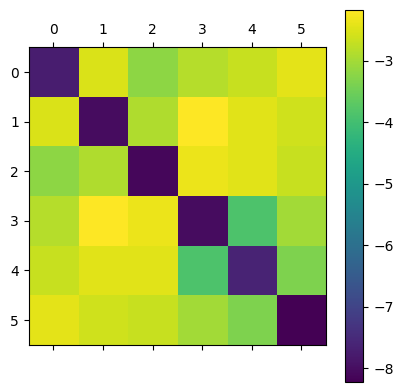

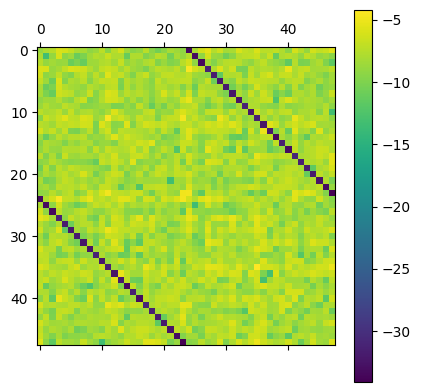

In [ ]:
(sb,sbb,stn,db,atcg,reps,ssm)=show_nanostar_stats(uber6_targetG,ubersticky6nanostars)

This is the first set of 16 nanostars with palindromic 8-mer sticky ends and T spacers, but which was decided agained because of a GGGG sequence.  It was designed prior to that prohibition being added.  We won't use these sequences.

In [ ]:
ubersticky16nanostars

In [ ]:
ubersticky16nanostars=\
   ['GGATTCACTGTAGGCCACATTTGCGTCCGACACTGAACTATGTTATCGATA',
 'CATAGTTCAGTGTCGGACGCTTTGTCAGCCGTGCTATCAAGATTATCGATA',
 'TCTTGATAGCACGGCTGACATTACGGTCTGACCCGAAATAGTTTATCGATA',
 'ACTATTTCGGGTCAGACCGTTTATGTGGCCTACAGTGAATCCTTATCGATA',
 'TGGATCAGCACCGATACTTGTTTTGACCACCTAGGATGCGTTTTCATATGA',
 'AACGCATCCTAGGTGGTCAATTCGGAGACTAGATGATTTCCGTTCATATGA',
 'CGGAAATCATCTAGTCTCCGTTGATGTCTAACGATTCAGGCCTTCATATGA',
 'GGCCTGAATCGTTAGACATCTTCAAGTATCGGTGCTGATCCATTCATATGA',
 'GACTACGTTGACGGATCTCATTCAACACACTATGGTCGCGTTTGTAATTAC',
 'AACGCGACCATAGTGTGTTGTTCGCGTACATGGTGGACTAAATGTAATTAC',
 'TTTAGTCCACCATGTACGCGTTATCCGCAAGATGCTGCTTAGTGTAATTAC',
 'CTAAGCAGCATCTTGCGGATTTTGAGATCCGTCAACGTAGTCTGTAATTAC',
 'ATGTAACAACCGTTCGGCCTTTGCTATGCCCAGACTGGTAGATCAATATTG',
 'TCTACCAGTCTGGGCATAGCTTCTAAGTGCGAGGCTTGTCACTCAATATTG',
 'GTGACAAGCCTCGCACTTAGTTCTACTCGTCAGGTCTAGCAGTCAATATTG',
 'CTGCTAGACCTGACGAGTAGTTAGGCCGAACGGTTGTTACATTCAATATTG',
 'AGTTGTCGTCATACCGTCCATTTGGCACAATTAGCTGGTCCATACTTAAGT',
 'TGGACCAGCTAATTGTGCCATTCTAACAGGCAGTGGTTTCGCTACTTAAGT',
 'GCGAAACCACTGCCTGTTAGTTGTGCATCATAGTCACGTCAGTACTTAAGT',
 'CTGACGTGACTATGATGCACTTTGGACGGTATGACGACAACTTACTTAAGT',
 'ACGGGTAACGCAATGTTGACTTGTAGTGACTCGACCTATTCCTAGTATACT',
 'GGAATAGGTCGAGTCACTACTTTGTGACGCCATGCACCTATGTAGTATACT',
 'CATAGGTGCATGGCGTCACATTCGAACCTTGTGAGGTCCTAATAGTATACT',
 'TTAGGACCTCACAAGGTTCGTTGTCAACATTGCGTTACCCGTTAGTATACT',
 'GCAAACCTCAATGGGTTCTGTTTGAACCGATGCCAGGGCTCTTGTTATAAC',
 'AGAGCCCTGGCATCGGTTCATTAGTTTGGAGCCTATACCCCATGTTATAAC',
 'TGGGGTATAGGCTCCAAACTTTGACAGATACATCGTCTTCGGTGTTATAAC',
 'CCGAAGACGATGTATCTGTCTTCAGAACCCATTGAGGTTTGCTGTTATAAC',
 'TGAAGCCACACGTACTGTTCTTGTATTGCTTGAGCACAGCTCTTATGCATA',
 'GAGCTGTGCTCAAGCAATACTTCTACCTCAGCGCTATTGGAGTTATGCATA',
 'CTCCAATAGCGCTGAGGTAGTTGAGTGTAGCCGAGTTCAACTTTATGCATA',
 'AGTTGAACTCGGCTACACTCTTGAACAGTACGTGTGGCTTCATTATGCATA',
 'TAGTAAGCGCAGATCGTACCTTACCGCATGTGTGCCTAAAAGTCTTTAAAG',
 'CTTTTAGGCACACATGCGGTTTTGGCCAGAATCGAAGTTTCTTCTTTAAAG',
 'AGAAACTTCGATTCTGGCCATTGGTAATGCGAGCCATATCTCTCTTTAAAG',
 'GAGATATGGCTCGCATTACCTTGGTACGATCTGCGCTTACTATCTTTAAAG',
 'GAACACTTGGTCACCGTCGTTTAGCAGGCAATCGCTGTCTGTTGATTAATC',
 'ACAGACAGCGATTGCCTGCTTTACTGTCCTACGCTAAGATGGTGATTAATC',
 'CCATCTTAGCGTAGGACAGTTTGCAAGCGTGTCTGCAATTCATGATTAATC',
 'TGAATTGCAGACACGCTTGCTTACGACGGTGACCAAGTGTTCTGATTAATC',
 'AACATATGCGCGATCCTCGGTTTAACCGGATCACCCTGTGTATCATTAATG',
 'TACACAGGGTGATCCGGTTATTCATCGATCATGGAGCATGTCTCATTAATG',
 'GACATGCTCCATGATCGATGTTCCTGCACTAGCATGACTGTGTCATTAATG',
 'CACAGTCATGCTAGTGCAGGTTCCGAGGATCGCGCATATGTTTCATTAATG',
 'CCCTGCTGTGGTACTAGAGCTTTGCACGATCAGATTAGGGTCTTTGTACAA',
 'GACCCTAATCTGATCGTGCATTTGAGCGGAATGCCGTCTCAATTTGTACAA',
 'TTGAGACGGCATTCCGCTCATTGTCCCAGTAGAGTACCCAGTTTTGTACAA',
 'ACTGGGTACTCTACTGGGACTTGCTCTAGTACCACAGCAGGGTTTGTACAA',
 'AGTGGACATTGTTCACCACGTTCCAGGATGACTTCAATCAGGTATCTAGAT',
 'CCTGATTGAAGTCATCCTGGTTGCGCCAACTGATATCGACTATATCTAGAT',
 'TAGTCGATATCAGTTGGCGCTTGTGTGATTCCACTCAGAAGCTATCTAGAT',
 'GCTTCTGAGTGGAATCACACTTCGTGGTGAACAATGTCCACTTATCTAGAT',
 'CTGGATAGACTCACTAGGCTTTCAAGGCTAGGCGATTACTCATATAGCTAT',
 'TGAGTAATCGCCTAGCCTTGTTGCATTGGCAACGACTGAGCTTATAGCTAT',
 'AGCTCAGTCGTTGCCAATGCTTATCAATTGGATGCCCTTGGCTATAGCTAT',
 'GCCAAGGGCATCCAATTGATTTAGCCTAGTGAGTCTATCCAGTATAGCTAT',
 'ACACATCTGGTCTTGAGGCGTTCACGAGATTGTATTCGGTCATTTACGTAA',
 'TGACCGAATACAATCTCGTGTTAGCTTAACGGACCTGGCGACTTTACGTAA',
 'GTCGCCAGGTCCGTTAAGCTTTTGGTTACCATCCCAAGTAGGTTTACGTAA',
 'CCTACTTGGGATGGTAACCATTCGCCTCAAGACCAGATGTGTTTTACGTAA',
 'ATACGAGTGCTCGACAGGTGTTGCGACATAGCCGTAGATTTCTAGAATTCT',
 'GAAATCTACGGCTATGTCGCTTCGTCCCGGTGTACCTAAGTATAGAATTCT',
 'TACTTAGGTACACCGGGACGTTGCTGCCGTATCACATAGATGTAGAATTCT',
 'CATCTATGTGATACGGCAGCTTCACCTGTCGAGCACTCGTATTAGAATTCT']


target G :    min      mean      max     RMS deviation from target    min/max deviation with spacer
    -2.0 :   -5.4     -3.3      -2.4             1.4                          -0.36/0.78
    -9.5 :  -10.3     -9.7      -9.3             0.3                          0.15/1.51

domain G :    min      mean      max     standard deviation from mean
     0.0 :  -17.3     -8.4      -3.7             1.6
   -30.0 :  -35.0    -32.8     -30.7             1.0

worst domain atcg deviation from 0.25, and std: 0.10, 0.03

number of length-n repeats for     n =    3    4    5    6
                                        521  258   67   26

number of length-n SSM clashes for n =    3    4    5    6    7    8    9    10
                                       3072 2816 2075  657  152   96   48    0

sticky-end / stem truncation robustness per target G :   min    mean    max    std
                                                -9.5 :  -0.7     1.6    5.4    0.8
                                       

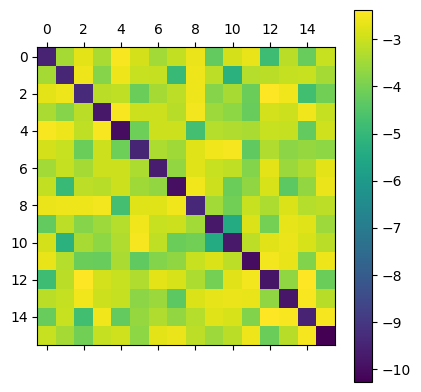

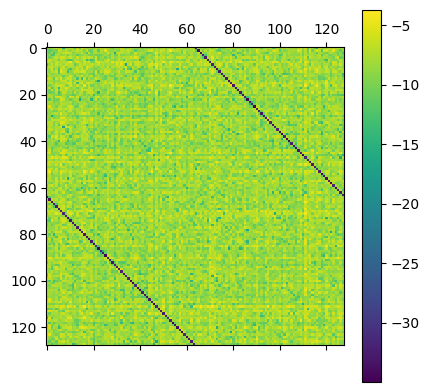

In [ ]:
(sb,sbb,stn,db,atcg,reps,ssm)=show_nanostar_stats(uber16_targetG,ubersticky16nanostars,spacer='T',stickylen=8)

Even earlier, we designed 16 nanostars with 8-mer palindrome sticky ends and A spacers. This has even more GGGG subsequences and also will not be used.

In [ ]:
# designed with earlier code that used mfe for everything and an 'A' spacer.
# this design is included here just for comparison -- it sure seems inferior!
# so don't use this, use the one above.
ubersticky16nanostarsA=\
   ['AAGATTGTAGACCCACGTTCAATCGAGACGAGCATTACTTCCACTACGTAG',
 'GGAAGTAATGCTCGTCTCGAAATGCTAGAGTGACATCTACCGACTACGTAG',
 'CGGTAGATGTCACTCTAGCAAAGACTTGTCGGAGCAGTAACAACTACGTAG',
 'TGTTACTGCTCCGACAAGTCAAGAACGTGGGTCTACAATCTTACTACGTAG',
 'CGCGGATGGATCGCTTATGCAATTGAGTGCTATGCCTCACACACCTATAGG',
 'GTGTGAGGCATAGCACTCAAAACCGATCTGGTGGTACCTAGAACCTATAGG',
 'TCTAGGTACCACCAGATCGGAAGTCCGGTATGCTAAACCCTTACCTATAGG',
 'AAGGGTTTAGCATACCGGACAAGCATAAGCGATCCATCCGCGACCTATAGG',
 'AGATAGTACCCTGGAGTCGCAAAACGAATCCTGTGTCCGATAAACAATTGT',
 'TATCGGACACAGGATTCGTTAAGGCCAATCCGCTTCAATTAGAACAATTGT',
 'CTAATTGAAGCGGATTGGCCAAGTGCAGTTATCCGAGATTACAACAATTGT',
 'GTAATCTCGGATAACTGCACAAGCGACTCCAGGGTACTATCTAACAATTGT',
 'TATGTGGCGACCGTCCTGACAAACGGTGCTCTGGCGAACAAGATGAATTCA',
 'CTTGTTCGCCAGAGCACCGTAACGCGTGGATAGGTTACACACATGAATTCA',
 'GTGTGTAACCTATCCACGCGAATGTGTTCCGTCAGACACAATATGAATTCA',
 'ATTGTGTCTGACGGAACACAAAGTCAGGACGGTCGCCACATAATGAATTCA',
 'CTAATGACTAGCGTGATGGCAACGGTTGAATAGTCCCACACTAAATGCATT',
 'AGTGTGGGACTATTCAACCGAACGGCCTAGTAGGTGATTTCAAAATGCATT',
 'TGAAATCACCTACTAGGCCGAAGTTGACCTACGATGAGCCCCAAATGCATT',
 'GGGGCTCATCGTAGGTCAACAAGCCATCACGCTAGTCATTAGAAATGCATT',
 'AGAAGTACGACTGTGCGTCTAAGTAAGTTTGGGTCACCACAAACCTTAAGG',
 'TTGTGGTGACCCAAACTTACAAACACCCCATAGGCTGATAAGACCTTAAGG',
 'CTTATCAGCCTATGGGGTGTAAACGCATGATGGTGCCTAACCACCTTAAGG',
 'GGTTAGGCACCATCATGCGTAAAGACGCACAGTCGTACTTCTACCTTAAGG',
 'ACTTTGAGCGACATAGAGACAACGTATGAGATGACCCGTTACATGTTAACA',
 'GTAACGGGTCATCTCATACGAAGTCACAGCTGAGCTGATGTAATGTTAACA',
 'TACATCAGCTCAGCTGTGACAAGACGGCTTCGCTGATCAATGATGTTAACA',
 'CATTGATCAGCGAAGCCGTCAAGTCTCTATGTCGCTCAAAGTATGTTAACA',
 'CTGTAGTATGGCAGATACCCAAGACTGCGTGTGGACAACCAAACCATATGG',
 'TTGGTTGTCCACACGCAGTCAACTGGCTGTCGAGCTACATACACCATATGG',
 'GTATGTAGCTCGACAGCCAGAAATCGTGATCTAGAGCCACTTACCATATGG',
 'AAGTGGCTCTAGATCACGATAAGGGTATCTGCCATACTACAGACCATATGG',
 'CGGTCAAACGTCATGATTGCAAGGTGGCATATCTATAGCCCTAGTCTAGAC',
 'AGGGCTATAGATATGCCACCAAGCGCATCTGCATGTAAGTAAAGTCTAGAC',
 'TTACTTACATGCAGATGCGCAAATCTGGAATCAGGCTATTACAGTCTAGAC',
 'GTAATAGCCTGATTCCAGATAAGCAATCATGACGTTTGACCGAGTCTAGAC',
 'AAACGGATACGTGTCTTAGCAACGATTCAAGTTGCCGTACCGAGGTATACC',
 'CGGTACGGCAACTTGAATCGAAACGGGACCCTATTGCGATTAAGGTATACC',
 'TAATCGCAATAGGGTCCCGTAAGATTAGTCGAGTTCCAGCCCAGGTATACC',
 'GGGCTGGAACTCGACTAATCAAGCTAAGACACGTATCCGTTTAGGTATACC',
 'CTTATTGGAACCAGCGGTACAAATCCCGTGGCAATGTACAGTAAAAGCTTT',
 'ACTGTACATTGCCACGGGATAAGTGACGTAAGCGTTGCACCAAAAAGCTTT',
 'TGGTGCAACGCTTACGTCACAAGGTCAGTCCAATTCGATGCCAAAAGCTTT',
 'GGCATCGAATTGGACTGACCAAGTACCGCTGGTTCCAATAAGAAAAGCTTT',
 'TGATAATGGCGTCCGAATACAACGACGTGTTGAAACCCGATTAGGATATCC',
 'AATCGGGTTTCAACACGTCGAACACCGACGACACTTTGGATGAGGATATCC',
 'CATCCAAAGTGTCGTCGGTGAAAACTGTATGAACTGCCGACCAGGATATCC',
 'GGTCGGCAGTTCATACAGTTAAGTATTCGGACGCCATTATCAAGGATATCC',
 'AGAACGACCTCCGTGTATAGAAGCGTACTGTTGATGCTACACATTTCGAAA',
 'GTGTAGCATCAACAGTACGCAATGCCAGGCCAGTATGACAGAATTTCGAAA',
 'TCTGTCATACTGGCCTGGCAAAGCTGGCTACTGAGTATATCGATTTCGAAA',
 'CGATATACTCAGTAGCCAGCAACTATACACGGAGGTCGTTCTATTTCGAAA',
 'AACTATGATCGTCAATGCTGAAGTTATAGCTGCAAGATCCCCACAGATCTG',
 'GGGGATCTTGCAGCTATAACAAACTAAGGCAGGTAGTCTCCAACAGATCTG',
 'TGGAGACTACCTGCCTTAGTAACTGGACGTTAGTATCACCCGACAGATCTG',
 'CGGGTGATACTAACGTCCAGAACAGCATTGACGATCATAGTTACAGATCTG',
 'AATCTAGTTAGCAGCACGCCAACATTTGACAGGTGTCTATCAAGAGTACTC',
 'TGATAGACACCTGTCAAATGAACCCAGTGAGTGGTTCACAACAGAGTACTC',
 'GTTGTGAACCACTCACTGGGAACATGGTAGTTCTGAGACCCGAGAGTACTC',
 'CGGGTCTCAGAACTACCATGAAGGCGTGCTGCTAACTAGATTAGAGTACTC',
 'TAATGGACCAATGTGCCCTGAAATGTCAGTTGGGCCACTACTACTCATGAG',
 'AGTAGTGGCCCAACTGACATAACATCCCAACGTGAAGTGATGACTCATGAG',
 'CATCACTTCACGTTGGGATGAAGCTCAACCTCGTGGTAAAACACTCATGAG',
 'GTTTTACCACGAGGTTGAGCAACAGGGCACATTGGTCCATTAACTCATGAG']


target G :    min      mean      max     RMS deviation from target    min/max deviation with spacer
    -2.0 :   -5.9     -2.9      -1.8             1.2                          -0.65/1.26
    -9.5 :  -12.3    -10.9     -10.1             1.6                          0.61/1.80

domain G :    min      mean      max     standard deviation from mean
     0.0 :  -16.3     -8.2      -3.3             1.6
   -30.0 :  -35.5    -32.5     -29.3             1.2

worst domain atcg deviation from 0.25, and std: 0.10, 0.04

number of length-n repeats for     n =    3    4    5    6
                                        550  294   65    2

number of length-n SSM clashes for n =    3    4    5    6    7    8    9    10
                                       3072 2816 2074  657  154   96   48    0

sticky-end / stem truncation robustness per target G :   min    mean    max    std
                                                -9.5 :   0.1     1.9    7.4    1.2
                                       

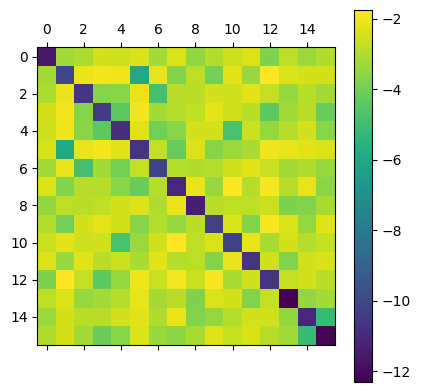

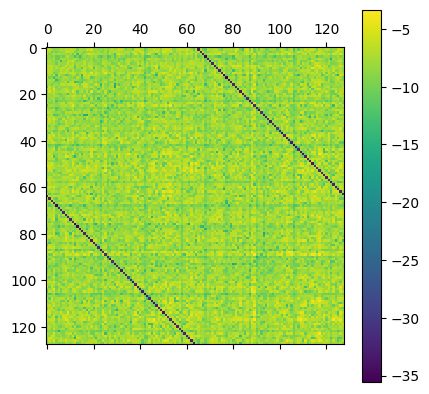

In [ ]:
(sb,sbb,stn,db,atcg,reps,ssm)=show_nanostar_stats(uber16_targetG,ubersticky16nanostarsA,spacer='A',stickylen=8)

As of 12/27/2023, Yancheng and Erik are both OK with the latest design, V2, which prohibits the GGGG.

In [ ]:
ubersticky16nanostarsV2

In [ ]:
ubersticky16nanostarsV2=\
  ['GGATTCACTGTAGGCCACATTTGCGTCCGACACTGAACTATGTTATCGATA',
 'CATAGTTCAGTGTCGGACGCTTTGTCAGCCGTGCTATCAAGATTATCGATA',
 'TCTTGATAGCACGGCTGACATTACGGTCTGACCCGAAATAGTTTATCGATA',
 'ACTATTTCGGGTCAGACCGTTTATGTGGCCTACAGTGAATCCTTATCGATA',
 'TGGATCAGCACCGATACTTGTTTTGACCACCTAGGATGCGTTTTCATATGA',
 'AACGCATCCTAGGTGGTCAATTCGGAGACTAGATGATTTCCGTTCATATGA',
 'CGGAAATCATCTAGTCTCCGTTGATGTCTAACGATTCAGGCCTTCATATGA',
 'GGCCTGAATCGTTAGACATCTTCAAGTATCGGTGCTGATCCATTCATATGA',
 'GACTACGTTGACGGATCTCATTCAACACACTATGGTCGTGTTTGTAATTAC',
 'AACACGACCATAGTGTGTTGTTCGCGTACATGTTGGACTAAATGTAATTAC',
 'TTTAGTCCAACATGTACGCGTTATCCGCAAGATGCTGCTTAGTGTAATTAC',
 'CTAAGCAGCATCTTGCGGATTTTGAGATCCGTCAACGTAGTCTGTAATTAC',
 'ATGTAACAACCGTTGGGCCTTTGCTATGCCCAGACTGGTAGATCAATATTG',
 'TCTACCAGTCTGGGCATAGCTTCTAAGTGCGAGGCTTGTCACTCAATATTG',
 'GTGACAAGCCTCGCACTTAGTTCTACTAGTCAGGTCTAGCAGTCAATATTG',
 'CTGCTAGACCTGACTAGTAGTTAGGCCCAACGGTTGTTACATTCAATATTG',
 'AGTTGTCGTCATACCGTCCATTTGGCACAATTAGCTGGTCCATACTTAAGT',
 'TGGACCAGCTAATTGTGCCATTCTAACAGGCAGTGGTTTCGCTACTTAAGT',
 'GCGAAACCACTGCCTGTTAGTTGTGCATCATAGTCACGTCAGTACTTAAGT',
 'CTGACGTGACTATGATGCACTTTGGACGGTATGACGACAACTTACTTAAGT',
 'ACGGGTATCGCAATGTTGACTTGTAGTGACTCGACCTATTCCTAGTATACT',
 'GGAATAGGTCGAGTCACTACTTTGTGATGCCATGCACCTATGTAGTATACT',
 'CATAGGTGCATGGCATCACATTCGAACCTTGTGAGGTCCTAATAGTATACT',
 'TTAGGACCTCACAAGGTTCGTTGTCAACATTGCGATACCCGTTAGTATACT',
 'GCAAACCTCAATGGGTTCTGTTTGAACCGATGACAGGGCTCTTGTTATAAC',
 'AGAGCCCTGTCATCGGTTCATTAGTTTGGAGCCTATACGCCATGTTATAAC',
 'TGGCGTATAGGCTCCAAACTTTGACAGATACATCGTCTTCGGTGTTATAAC',
 'CCGAAGACGATGTATCTGTCTTCAGAACCCATTGAGGTTTGCTGTTATAAC',
 'TGAAGCCACACGTACTGTTCTTGTATTGCTTGAGCACAGCTCTTATGCATA',
 'GAGCTGTGCTCAAGCAATACTTCTACCTCAGCGCTATTGGAGTTATGCATA',
 'CTCCAATAGCGCTGAGGTAGTTGAGTGTAGCCGAGTTCAACTTTATGCATA',
 'AGTTGAACTCGGCTACACTCTTGAACAGTACGTGTGGCTTCATTATGCATA',
 'TAGTAAGCGCAGATCGTACCTTACCGCATGTGTGCCTAAAAGTCTTTAAAG',
 'CTTTTAGGCACACATGCGGTTTTGGCCAGAATCGAAGTTCCTTCTTTAAAG',
 'AGGAACTTCGATTCTGGCCATTGGTAATGCGAGCCATATCTCTCTTTAAAG',
 'GAGATATGGCTCGCATTACCTTGGTACGATCTGCGCTTACTATCTTTAAAG',
 'GAACACTTGGTCACCGTCGTTTAGCAGGCAATCGCTGTCTGTTGATTAATC',
 'ACAGACAGCGATTGCCTGCTTTACTGTCCTACGCTAAGATGGTGATTAATC',
 'CCATCTTAGCGTAGGACAGTTTGCAAGCGTGTCTGCAATTCATGATTAATC',
 'TGAATTGCAGACACGCTTGCTTACGACGGTGACCAAGTGTTCTGATTAATC',
 'AACATATGCGCGATCCTCGGTTTAACCGGATCACCCTGTGTATCATTAATG',
 'TACACAGGGTGATCCGGTTATTCATCGATCATGGAGTATGTCTCATTAATG',
 'GACATACTCCATGATCGATGTTCCTGCACTAGCATGACTGTGTCATTAATG',
 'CACAGTCATGCTAGTGCAGGTTCCGAGGATCGCGCATATGTTTCATTAATG',
 'CCCTACTGTGGGATTAGAGCTTTGCACGATCAGATTAGGGTCTTTGTACAA',
 'GACCCTAATCTGATCGTGCATTTGAGCGGAATGCCGTCTCAATTTGTACAA',
 'TTGAGACGGCATTCCGCTCATTGTCCCAGTAGAGTACCCAGTTTTGTACAA',
 'ACTGGGTACTCTACTGGGACTTGCTCTAATCCCACAGTAGGGTTTGTACAA',
 'AGTGGACATTGTTCACCACGTTCCAGGATGACTTCAATCAGGTATCTAGAT',
 'CCTGATTGAAGTCATCCTGGTTGCGGCAACTGATATCGACTATATCTAGAT',
 'TAGTCGATATCAGTTGCCGCTTGTGTGATTCCACTCAGAAGCTATCTAGAT',
 'GCTTCTGAGTGGAATCACACTTCGTGGTGAACAATGTCCACTTATCTAGAT',
 'CTGGATAGACTCACTGGGCTTTCAAGGCTAGGCGATTACTCATATAGCTAT',
 'TGAGTAATCGCCTAGCCTTGTTGCATTGGCAACGACTGAGCTTATAGCTAT',
 'AGCTCAGTCGTTGCCAATGCTTATCAATTGGATGCCCTTGGCTATAGCTAT',
 'GCCAAGGGCATCCAATTGATTTAGCCCAGTGAGTCTATCCAGTATAGCTAT',
 'ACACATCTGGTTATGAGGCGTTCACGAGATTGTATTCGGTCATTTACGTAA',
 'TGACCGAATACAATCTCGTGTTAGCTTAACTGACCTGGCGACTTTACGTAA',
 'GTCGCCAGGTCAGTTAAGCTTTTGGTTACCATCCCATGTAGGTTTACGTAA',
 'CCTACATGGGATGGTAACCATTCGCCTCATAACCAGATGTGTTTTACGTAA',
 'ATACGAGTGCTCCACAGGTGTTGCGACATAGCCGTAGATTTCTAGAATTCT',
 'GAAATCTACGGCTATGTCGCTTCGTCACGGTGTACCTAAGTATAGAATTCT',
 'TACTTAGGTACACCGTGACGTTGCTGCCGTATCACATAGATGTAGAATTCT',
 'CATCTATGTGATACGGCAGCTTCACCTGTGGAGCACTCGTATTAGAATTCT']

In [ ]:
uber16_targetG=[[ -9.5 if i==j else -2.0 for i in range(16)] for j in range(16)]


target G :    min      mean      max     RMS deviation from target    min/max deviation with spacer
    -2.0 :   -5.4     -3.3      -2.4             1.4                          -0.36/0.78
    -9.5 :  -10.3     -9.7      -9.3             0.3                          0.15/1.51

domain G :    min      mean      max     standard deviation from mean
     0.0 :  -17.3     -8.4      -3.7             1.6
   -30.0 :  -34.8    -32.7     -30.2             0.9

worst domain atcg deviation from 0.25, and std: 0.05, 0.03

number of length-n repeats for     n =    3    4    5    6
                                        515  256   65   26

number of length-n SSM clashes for n =    3    4    5    6    7    8    9    10
                                       3072 2818 2077  672  154   96   48    0

sticky-end / stem truncation robustness per target G :   min    mean    max    std
                                                -9.5 :  -0.7     1.6    5.4    0.8
                                       

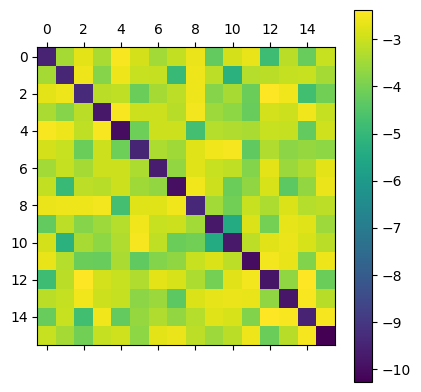

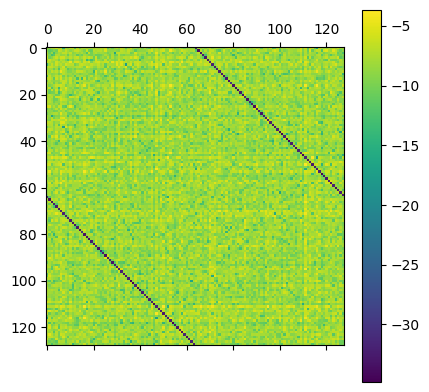

In [ ]:
(sb,sbb,stn,db,atcg,reps,ssm)=show_nanostar_stats(uber16_targetG,ubersticky16nanostarsV2,spacer='T',stickylen=8)

In [ ]:
print(sbb)
#plt.matshow(sbb)

[[-9.499025791883469, -3.449046105146408, -2.689312383532524, -3.3845238089561462, -2.4691032767295837, -2.89668408036232, -3.4853981882333755, -3.097809962928295, -2.611533507704735, -4.261987268924713, -2.8803470879793167, -2.6529965177178383, -4.835785306990147, -3.1801512092351913, -4.218881145119667, -3.041244551539421], [-3.44904562830925, -9.436285942792892, -2.569638654589653, -3.8255109190940857, -2.576938807964325, -3.0453948080539703, -3.079238310456276, -4.958855800330639, -2.5782664865255356, -3.1649215817451477, -5.234565570950508, -3.256950832903385, -3.1852862015366554, -3.078310951590538, -3.034799352288246, -3.452708289027214], [-2.689312383532524, -2.569639131426811, -9.325274348258972, -3.192616358399391, -3.1202336698770523, -4.141870364546776, -3.4351089894771576, -3.1606971099972725, -2.5664549469947815, -3.8127515465021133, -3.397187262773514, -4.14718621224165, -2.4006107971072197, -2.5349943041801453, -4.760727614164352, -4.067881107330322], [-3.38452380895614

# Initial attempts at sticky end sequences for Hopfield droplets

Instead of palindromes, we go back to the original "match the binding matrix" approach.  

To get in the right ballpark, recall that ViennaRNA thinks of sticky end strengths that work in the lab (Olivia's and Yancheng's) are from -8.0 to -10.0 kcal/mol, and that off-diagonal interactions are from -2.3 to -3.3 kcal/mol.

#### 5x5 binary images, binary Hebbian weights

Now we will test the ability to design a structured interaction matrix rather than just an orthogonal one!

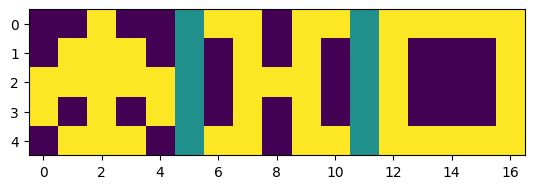

In [ ]:
smallshapes=[
    [[0,0,1,0,0],[0,1,1,1,0],[1,1,1,1,1],[1,0,1,0,1],[0,1,1,1,0]], # 15 bits on
    [[1,1,0,1,1],[0,1,0,1,0],[0,1,1,1,0],[0,1,0,1,0],[1,1,0,1,1]], # 15 bits on
    [[1,1,1,1,1],[1,0,0,0,1],[1,0,0,0,1],[1,0,0,0,1],[1,1,1,1,1]]  # 16 bits on
  ]
plt.imshow(np.concatenate([ smallshapes[0], [[.5],[.5],[.5],[.5],[.5]], smallshapes[1], [[.5],[.5],[.5],[.5],[.5]], smallshapes[2] ], axis=1))
smallpats01=[ [ val for row in shape for val in row ] for shape in smallshapes ]

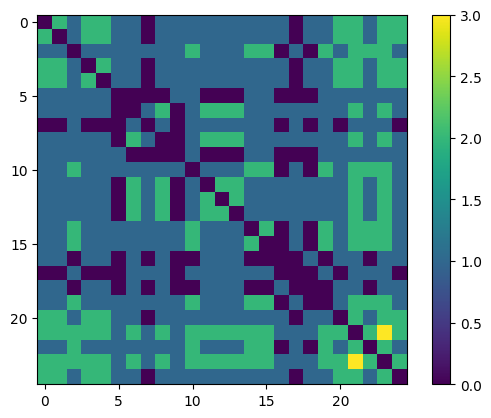

In [ ]:
# Hebbian weights for binary 0-1 network, which isn't as good as Hopfield Hebbian spin weights even with a well-chosen threshold, but in any case it's just a test
smallweights01=[[0 for i in range(25)] for j in range(25)]
for vector in smallpats01:
  for i in range(25):
    for j in range(25):
      smallweights01[i][j] += 0 if i==j else vector[i]*vector[j]
plt.imshow(smallweights01)
plt.colorbar()

In [ ]:
# This matrix isn't particularly good.
# Empirically tweaked biases allow it to stabilize target patterns... but other inputs often go all-on or all-off.
# And in any case, what do biases correspond to in phase separation?
x=np.array([random.choice([0,1]) for i in range(25)])
#x=np.array(smallpats01[0])
print(x)
smallbias01=-np.array([sum([smallweights01[i][j] for j in range(25)]) for i in range(25)])*.6
while not all(np.heaviside(smallbias01 + smallweights01 @ x,0)==x):
  i=random.randint(1,len(x))-1
  x[i]=((smallbias01[i] + smallweights01[i] @ x)>0)
print(x)
[ all(x==smallpats01[i]) for i in range(3) ] + [ all(1-x==smallpats01[i]) for i in range(3) ]

[0 1 0 0 1 1 0 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 1 1 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


[False, False, False, False, False, False]

In [ ]:
smallpats01

[[0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0],
 [1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1],
 [1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1]]

In [ ]:
# We seldom see binding less than -2 kcal/mol from ViennaRNA. Curious how small ViennaRNA's binding energies can get, and what's their offset.
binding_matrix(['TCAAAAAAAAAG','GACCCCCCCT'])

[[-1.4093803614377975, -2.7778022810816765],
 [-2.7778022810816765, -1.855764091014862]]

In [ ]:
# design sticky ends anyway.  just a test.
strands=random_strands(25,10) # 25 sticky ends of length 10
# for yancheng's 4-nanostar 6-mer sticky ends, "non-interacting" is around -2.5 kcal/mol, while "binding" is around -8.5 kcal/mol
# for no particular reason, this test aims for dG=-12 kcal/mol if pair is in two vectors, and -2 if non-interacting
smalltargetG01=[ [ -2.0-5.0*smallweights01[i][j] for i in range(25)] for j in range(25) ]
strands=minimize_matrix_imperfection(strands,10000,1,smalltargetG01, avoid=['GGGG','SSSSS','WWWWWW']) # about 25 min for 3 muts at at time; faster 10 min for 1 at a time
smallstrands01=strands

In [ ]:
# we're not so happy with it, but for the record, here is the best design so far
smallstrands01=\
 ['CTGCACGTCC',
 'GCACTGTCCG',
 'CGCATGCATC',
 'GTGCAGACCT',
 'GTGCAGGTCC',
 'GCATATACGG',
 'TGCGCACCTG',
 'TTGCGCTTGC',
 'GCGCACCTGT',
 'GTGTCATGTC',
 'TGTGCATGCC',
 'CTTGGTGCGC',
 'GCGCAGCCTG',
 'GGTGCGCTGC',
 'AGTGCATGCC',
 'TTGTGCATGC',
 'ACGGTCCAGG',
 'TGCTTCGCAT',
 'ACGGTCCAGG',
 'TGTGCATGCC',
 'GACGCTGCAT',
 'TAGGCGTGCG',
 'CGTCGCATGC',
 'TGCAGGCACG',
 'ACGGACTGCA']

total  3070.096557848668  ==> mse  4.912154492557869


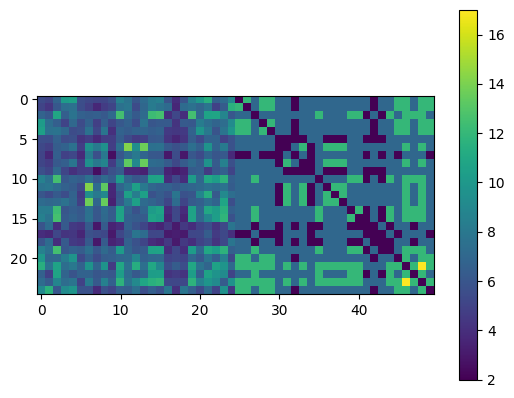

In [ ]:
print('total ',matrix_score_strands(smallstrands01,smalltargetG01),' ==> mse ', matrix_score_strands(smallstrands01,smalltargetG01)/25/25)
smallGdesigned01=np.array(binding_matrix(smallstrands01))
plt.imshow(np.concatenate([-smallGdesigned01,-np.array(smalltargetG01)],axis=1))
plt.colorbar()

The matrices have some similar flavor, so this is an encouraging test of design capability, especially since the optimization hadn't yet plateaued, but we are not yet sure exactly what matrix to target in order to get "Hopfield droplets" or "associative memory" or "pattern recognition" behaviors.  That will be assessed in the next section, where we will see that, surprisingly, this purely "attractive" target binding matrix ($X_{i,j} \le 0$ due to $\Delta G_{i,j}=0$) and its design approximation are more effective than one might expect.

In the meantime, we might be concerned that the 0/1 binary Hebbian learning, for 3 patterns, gave rise to 4 levels in the target weights: 0 to 3 prior to scaling.  Would it be easier to design sequences if the weights were just two values, for "interacting" versus "non-interacting"?  And does is violate the liquid assumptions if any interactions are too strong, putting an upper bound on the strongest weight... and thus making the more important intermediate weights too weak by contrast? For sticky ends in the "few seconds" transient range, that suggests a limit of -10 kcal/mol.

#### Can we improve the sequence design search? (this algorithm isn't it)

In [ ]:
smalltargetG01=[ [ -2.0-5.0*smallweights01[i][j] for i in range(25)] for j in range(25) ]

In [ ]:
def satisfy_matrix_constraints(strands,targetG,tolerance=1.0,strandlen=10,avoid=['GGGG','SSSS'],timeout=1000):
  strands=copy.deepcopy(strands)
  N=len(targetG)
  if isinstance(tolerance,(int,float)): # tolerance can be an array of the same size as targetG
    tolerance=[[tolerance for _ in range(N)] for _ in range(N)]
  devs = [ [ abs(binding_pair( (strands[i],strands[j]) )-targetG[i][j]) for i in range(N) ] for j in range(N) ]
  conflicts = [ [ devs[i][j] > tolerance[i][j] for i in range(N) ] for j in range(N) ]
  voided = [ avoid_constraint(strands[i],avoid) for i in range(N) ]
  print(sum(voided),' prohibited subsequences')

  step=0
  last=0
  while any(voided) or np.sum(conflicts)>0:
    step+=1
    # chose a strand that has a problem...
    if any(voided):
      n=np.argmax(voided)
    else:
      n=random.choices(range(N), weights=np.sum(conflicts,axis=0))[0]

    # no tolerance for sequences with prohibited subsequences
    while voided[n] or step>last+timeout:
      if step>last+timeout:
        print("====> resetting strand ",n)
      else:
        print('reducing ',sum(voided),' prohibited subsequences')
      last=step
      strands[n]=random_strands(1,strandlen)[0]
      voided[n] = avoid_constraint(strands[n],avoid)
      if not voided[n]: # reconstruct conflicts matrix
        for i in range(N):
          ok = ( abs(binding_pair( (strands[i],strands[n]) )-targetG[i][n]) > tolerance[i][n] )
          conflicts[i][n]=ok
          conflicts[n][i]=ok

    # now make a mutation and accept the change if the number of conflicts stays the same or goes down
    ok=False
    while not ok:
      chars=list(strands[n])
      chars[random.randint(0,strandlen-1)]=random.choice('ACGT')
      string=''.join(chars)
      ok = (not string==strands[n] and not avoid_constraint(string,avoid))

    newdevrow = [ abs(binding_pair( (strands[i],string) )-targetG[i][n]) for i in range(N) ]
    newconflictrow = [ newdevrow[i] > tolerance[i][n] for i in range(N) ]
    if sum(newconflictrow) < sum(conflicts[n]) or (sum(newconflictrow) == sum(conflicts[n]) and sum(newdevrow)<sum(devs[n])):
      if sum(newconflictrow) < sum(conflicts[n]):
        print(f'step {step}: fixed strand {n}, now {np.sum(conflicts)} conflicts')
      else:
        print(f'step {step}: improved strand {n} from {sum(devs[n])} to {sum(newdevrow)} deviation')
      last=step
      strands[n]=string
      for i in range(N):
        devs[i][n]=newdevrow[i]
        devs[n][i]=newdevrow[i]
        conflicts[i][n]=newconflictrow[i]
        conflicts[n][i]=newconflictrow[i]

  return strands

In [ ]:
# how to use it: start with an easy constraint, then run again with current strands and try to improve them, then give up.
newsmallstrands01=random_strands(25,10)
newsmallstrands01=satisfy_matrix_constraints(newsmallstrands01,smalltargetG01,tolerance=6,timeout=3000)

In [ ]:
# may take another 3 min after the 3 min above -- but it's really not very good.  minimize_matrix_imperfection has a lower mse.
newsmallstrands01=satisfy_matrix_constraints(newsmallstrands01,smalltargetG01,tolerance=5.75,timeout=3000)

total  5405.750778539598  ==> mse  8.649201245663358


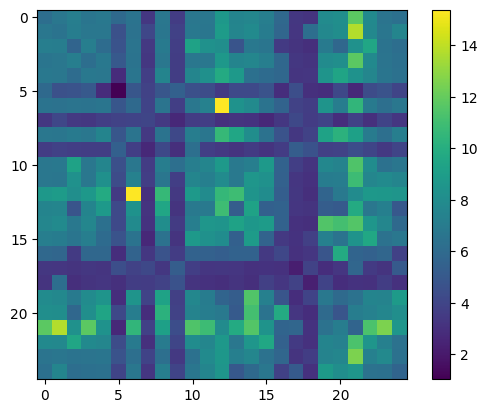

In [ ]:
print('total ',matrix_score_strands(newsmallstrands01,smalltargetG01),' ==> mse ', matrix_score_strands(newsmallstrands01,smalltargetG01)/25/25)
newsmallGdesigned01=np.array(binding_matrix(newsmallstrands01))
plt.imshow(-newsmallGdesigned01)
plt.colorbar()

#### Maybe spin weights for the same 5x5 are easier to design for?

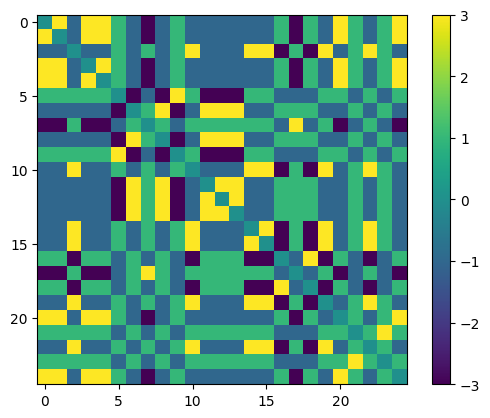

In [ ]:
# Hebbian weights for spin network
smallpats=[ [ 2*v-1 for v in pat] for pat in smallpats01 ]
smallweights=[[0 for i in range(25)] for j in range(25)]
for vector in smallpats:
  for i in range(25):
    for j in range(25):
      smallweights[i][j] += 0 if i==j else vector[i]*vector[j]
plt.imshow(smallweights)
plt.colorbar()

In [ ]:
# this works pretty well
x=np.array([random.choice([-1,+1]) for i in range(25)])
#x=np.array(smallpats[0])
print(x)
while not all(np.sign(smallweights @ x)==x):
  i=random.randint(1,len(x))-1
  x[i]=np.sign(smallweights[i] @ x)
print(x)
[ all(x==smallpats[i]) for i in range(3) ] + [ all(-x==smallpats[i]) for i in range(3) ]

[-1  1  1  1 -1 -1 -1 -1  1  1 -1 -1 -1 -1  1  1 -1  1 -1 -1 -1 -1 -1 -1
  1]
[-1 -1  1 -1 -1  1 -1  1 -1  1  1 -1 -1 -1  1  1 -1  1 -1  1 -1 -1  1 -1
 -1]


[False, False, False, False, True, False]

In [ ]:
# weights from -3 to 0 to +3 should correspond to binding strengths -2 to -7 to -12
strands=random_strands(25,10) # 25 sticky ends of length 10
smalltargetG=[ [ -7.0-5.0*smallweights[i][j]/3.0 for i in range(25)] for j in range(25) ]
strands=minimize_matrix_imperfection(strands,10000,1,smalltargetG, avoid=['GGGG','SSSSS','WWWWWW']) # about 10 min
smallstrands=strands

In [ ]:
# probably at a local minimum if > 3000 single-mutation steps yield no improvement.  let's try to get there
strands=minimize_matrix_imperfection(strands,10000,1,smalltargetG, avoid=['GGGG','SSSSS','WWWWWW']) # about 1 min
smallstrands=strands

step 137: score=2274.5751646987133


In [ ]:
# can a pair of mutations get us out of the local minimum? nope!
strands=minimize_matrix_imperfection(strands,10000,2,smalltargetG, avoid=['GGGG','SSSSS','WWWWWW']) # about 1 min
smallstrands=strands

In [ ]:
# best design results so far
smallstrands=\
 ['AGCATGGTCA',
 'GCACCATGGT',
 'TTCCGGAGCT',
 'ATGCACATGG',
 'CATGGGCATG',
 'AGCTCCCATG',
 'CGCGTGTTCA',
 'ACTCGAAGCG',
 'AGAACGCGTG',
 'GCTCCATGGG',
 'GATCCGGAGC',
 'AGACGCGTAA',
 'AAGACGCGTA',
 'TGAACGCGTG',
 'ATGAGCTCCG',
 'AGAGCTCCGA',
 'ACCACATGCG',
 'ACGCTTCGGA',
 'ATGCGTGTGG',
 'TCCGAGCTCC',
 'TACCATGCAC',
 'GCGTGCTCAT',
 'TCCGGAGCTT',
 'ATGGCTCGCG',
 'GACCATGGCA']

total  1632.8784074858836  ==> mse  2.6126054519774136


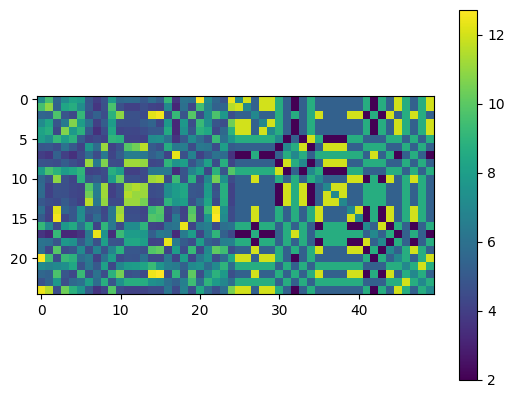

In [ ]:
print('total ',matrix_score_strands(smallstrands,smalltargetG),' ==> mse ', matrix_score_strands(smallstrands,smalltargetG)/25/25)
smallGdesigned=np.array(binding_matrix(smallstrands))
plt.imshow(np.concatenate([-smallGdesigned,-np.array(smalltargetG)],axis=1))
plt.colorbar()

In [ ]:
# clipped weights works pretty well too
smallweightsclip=np.clip(smallweights,-1,+1)
x=np.array([random.choice([-1,+1]) for i in range(25)])
#x=np.array(smallpats[0])
print(x)
while not all(np.sign(smallweightsclip @ x)==x):
  i=random.randint(1,len(x))-1
  x[i]=np.sign(smallweightsclip[i] @ x)
print(x)
[ all(x==smallpats[i]) for i in range(3) ] + [ all(-x==smallpats[i]) for i in range(3) ]

[ 1  1  1 -1 -1  1 -1 -1  1  1 -1  1  1  1  1  1  1 -1 -1 -1  1  1  1 -1
 -1]
[-1 -1  1 -1 -1  1 -1  1 -1  1  1 -1 -1 -1  1  1 -1  1 -1  1 -1 -1  1 -1
 -1]


[False, False, False, False, True, False]

In [ ]:
# is it easier to design weights that are less graded?
strands=random_strands(25,10) # 25 sticky ends of length 10
smalltargetGclip=[ [ -7.0-5.0*smallweightsclip[i][j] for i in range(25)] for j in range(25) ]
strands=minimize_matrix_imperfection(strands,20000,1,smalltargetGclip, avoid=['GGGG','SSSSS','WWWWWW']) # about 10 min
smallstrandsclip=strands

In [ ]:
strands=smallstrandsclip
strands=minimize_matrix_imperfection(strands,20000,1,smalltargetGclip, avoid=['GGGG','SSSSS','WWWWWW']) # about 10 min
smallstrandsclip=strands

In [ ]:
smallstrandsclip=\
 ['TTGACGGACG',
 'ACGGACGTCA',
 'ATGCATCGGA',
 'CGGACGTCAA',
 'GGACGTCACG',
 'TGCGTCCGAT',
 'ACAGCTGGAC',
 'CAGCTTGCAT',
 'CAGCTGGACA',
 'CGTGCGTCCG',
 'GGATGCATGC',
 'CACAGCTGGA',
 'GGACCCAGCT',
 'CAGCTGGACT',
 'GATGCATGCC',
 'AAGGATGCAT',
 'ACGTCCAGTC',
 'AGCCAGCATC',
 'TCGTCCAGTC',
 'TCGGATGCAT',
 'GACGGACGTT',
 'CCAGCGTCCG',
 'TTCGGATGCA',
 'GCGTCCGGTG',
 'GACGGACGTC']

total  4959.360146720918  ==> mse  7.934976234753469


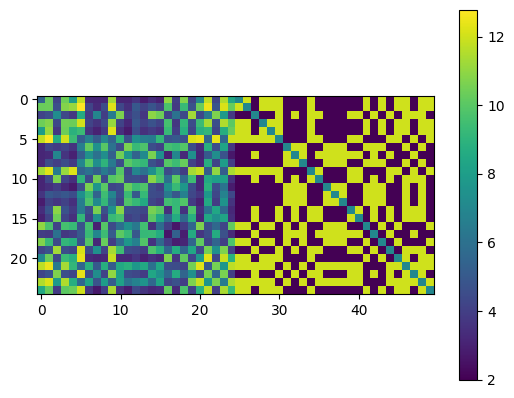

In [ ]:
print('total ',matrix_score_strands(smallstrandsclip,smalltargetGclip),' ==> mse ', matrix_score_strands(smallstrandsclip,smalltargetGclip)/25/25)
smallGdesignedclip=np.array(binding_matrix(smallstrandsclip))
plt.imshow(np.concatenate([-smallGdesignedclip,-np.array(smalltargetGclip)],axis=1))
plt.colorbar()

This looks all nice and good... but a higher error than the graded spin design.

Do these sticky ends work better?  That's hard to determine from the design score -- clearly, here we didn't hit the target as well, but possibly phase separation will be as good or better still.  Not impossible.

#### 5x5 patterns implemented in dual rail (both graded and clipped weights)

In [ ]:
# Finally, we will make a 50-species dual-rail implementation.

def dual_rail_targetG(spinweights,strongestG,weakestG):
  N=len(spinweights)
  maxweight=np.max(np.abs(spinweights))
  dualweights=[ [weakestG for _ in range(2*N)] for _ in range(2*N)]
  for i in range(N):
    for j in range(N):
      if spinweights[i][j]>0:
        dualweights[i][j]=strongestG*spinweights[i][j]/maxweight
        dualweights[i+N][j+N]=strongestG*spinweights[i][j]/maxweight
      if spinweights[i][j]<0:
        dualweights[i][j+N]=-strongestG*spinweights[i][j]/maxweight
        dualweights[i+N][j]=-strongestG*spinweights[i][j]/maxweight
  return dualweights

In [ ]:
# is it easier to design weights that are less graded?
strands=random_strands(50,12) # 50 sticky ends of length 12
smalltargetGdual=dual_rail_targetG(smallweights,strongestG=-14.0,weakestG=-2.0)
strands=minimize_matrix_imperfection(strands,30000,1,smalltargetGdual, avoid=['GGGG','SSSSS','WWWWWW']) # about 60 min
smallstrandsdual=strands

In [ ]:
# for n = 12 * 50 nt, probably at a local minimum if > n ln n = 4000 single-mutation steps yield no improvement.  let's try to get there
strands=minimize_matrix_imperfection(strands,15000,1,smalltargetGdual, avoid=['GGGG','SSSSS','WWWWWW']) # about 5 min
smallstrandsdual=strands

In [ ]:
# can a pair of mutations get us out of the local minimum? nope!
strands=minimize_matrix_imperfection(strands,20000,2,smalltargetGdual, avoid=['GGGG','SSSSS','WWWWWW']) # about 3 min
smallstrandsdual=strands

In [ ]:
smallstrandsdual=\
 ['CCTGGGATCCTG',
 'CCTGGGATCCTA',
 'CGTTCGACGGTC',
 'CCCAGGAGATCC',
 'TTCCAGATCCCA',
 'GCTCCCGAGCTC',
 'TTGCACAAGTGT',
 'TACAACAACGTT',
 'GTAGCAATGCAC',
 'GAGACTCGGAGC',
 'GTTCGACGGTCG',
 'TGCTTGCTACAA',
 'AAGTGCAGCAAG',
 'CTTGTGCAATTG',
 'GTTCGACCGTCG',
 'GAAGACGGTCGA',
 'TACTAGTGGCAC',
 'TAAACAACAACG',
 'CTAGTGGCATAG',
 'TCGACCGTCGTT',
 'GGGATCTCCAGG',
 'CACGGATTCGCA',
 'CGACGGTCGAAC',
 'TAAGCGAATCCG',
 'GGATCCCTGGAA',
 'CAACGTTGTTTT',
 'AACGTTGTTGAA',
 'GCATATCACTAG',
 'AAAACAACAACG',
 'AACAACGTTGTA',
 'TGCAATGCTGTG',
 'AGAGCTCGGAGG',
 'CTGGGATCCCTG',
 'GAGCTCCTCGAG',
 'GCATTGCACTTG',
 'GCCACTAGTGAT',
 'GAGCTCGAGGAG',
 'CCTCGGGAGTCT',
 'CCCGAGAGCTCG',
 'TAGTGGCATAGT',
 'GATATGCCACTA',
 'TGTTCGACGTCG',
 'GGATCCCTGGAG',
 'CGGTCGAACGTC',
 'ATGGCCACTAGT',
 'CGTTGTTGTTAT',
 'GAGTTAGTAAAA',
 'GCCCTAGTGATA',
 'TGTTACTAACTC',
 'ATAACGTTGTTG']

total  10864.939653823196  ==> mse  4.345975861529278


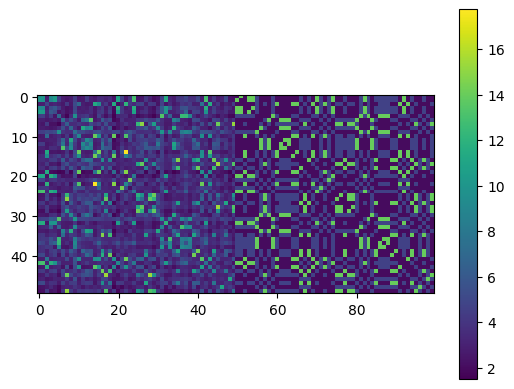

In [ ]:
print('total ',matrix_score_strands(smallstrandsdual,smalltargetGdual),' ==> mse ', matrix_score_strands(smallstrandsdual,smalltargetGdual)/50/50)
smallGdesigneddual=np.array(binding_matrix(smallstrandsdual))
plt.imshow(np.concatenate([-smallGdesigneddual,-np.array(smalltargetGdual)],axis=1))
plt.colorbar()

This actually looks pretty good.  Perhaps it could get a little better with a higher operating temperature, so it's easier to get non-interactions?  And easiter to accommodate longer strands?  That might be a good idea, but until we have easy access to a temperature-controlled microscope where we can consistently make long movies, it would be better to start with designing experiments that are likely to work at ambient room temperature, around 20 C to 25 C.   In that case, and because 50 nanostars is a lot, we should still investigate smaller patterns if we want to try the dual-rail approach.

In [ ]:
# is it easier to design weights that are less graded?
strands=random_strands(50,12) # 50 sticky ends of length 12
smalltargetGclipdual=dual_rail_targetG(smallweightsclip,strongestG=-14.0,weakestG=-2.0)
strands=minimize_matrix_imperfection(strands,30000,1,smalltargetGclipdual, avoid=['GGGG','SSSSS','WWWWWW']) # about 60 min
smallstrandsclipdual=strands

In [ ]:
smallstrandsclipdual

['TCCACGTTCGTC',
 'CCACCGTCACGT',
 'CCTTGGCCACTT',
 'AGAGCCGACGTC',
 'CCACGTTCGTCA',
 'CGACGGCTCCAT',
 'CTTGCGCACTTT',
 'CCCAGGGCAAGG',
 'GTTACCCTTGCG',
 'AAGGTGGACGTG',
 'ATCCTTGCCACC',
 'GCGTTGCCAGGG',
 'CCCTTGCGCACA',
 'CGTTGCAGGGTT',
 'TATGGCCTTGGT',
 'CCTTGGCCACCT',
 'TAGTGCGAACGG',
 'TGGTGCAAGGGA',
 'GAACGCAGGAAC',
 'GCCACCATCCTT',
 'ACCGACGTTCAC',
 'GACGTGGCAAGG',
 'TTGCCATGGACC',
 'GTGGCAAGGACG',
 'GTTCCACGTCGT',
 'CCCTGGCAAGAT',
 'TTGTGGCAAGGG',
 'GAATGTGACGCG',
 'TGGTGCAAGGGT',
 'CTTGGCAAGGGT',
 'CCTTGCTGCGCT',
 'GACGGTGGCCTT',
 'CCGTCACGTTCA',
 'AGGTGGACGTGG',
 'CCCTTGCGCACT',
 'GTGAACGTGCGC',
 'TGACGGTGGCCT',
 'ACGGTGGCCATC',
 'CAAGGAACGTGG',
 'GCGACGTGAGGG',
 'GCGACGGTGACA',
 'TATGGCCTTGGA',
 'ACACGTCACCTC',
 'TATCCTTGGCCA',
 'AGTGAACGCGTG',
 'ACCCTGGCAAGA',
 'GCCACCGTTCAC',
 'TGAACGTGCGCA',
 'GCCACCGTTCAT',
 'GGTTGGCAAGGG']

total  52656.824492905595  ==> mse  21.062729797162238


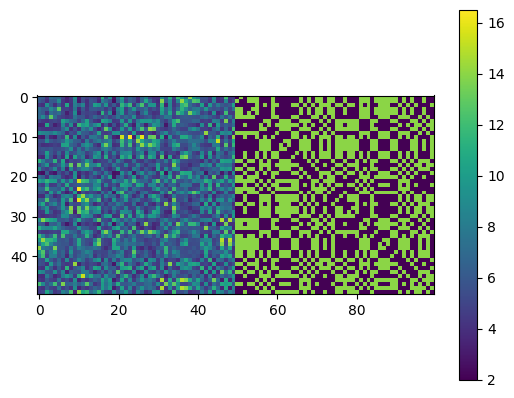

In [ ]:
print('total ',matrix_score_strands(smallstrandsclipdual,smalltargetGclipdual),' ==> mse ', matrix_score_strands(smallstrandsclipdual,smalltargetGclipdual)/50/50)
smallGdesignedclipdual=np.array(binding_matrix(smallstrandsclipdual))
plt.imshow(np.concatenate([-smallGdesignedclipdual,-np.array(smalltargetGclipdual)],axis=1))
plt.colorbar()

#### 4x4 images, spin Hopfield Hebbian weights, dual-rail DNA nanostar representation (not recently updated)

Let's see if we can get 3 memories (and their inverses) out of a 16-spin Hopfield network.  Then construct a delta-G interaction matrix for a dual-rail DNA liquid.

In [ ]:
tinypats01=np.array([
    [1,1,1,1,1,0,0,1,1,0,0,1,1,1,1,1],
    [1,0,0,1,0,1,1,0,0,1,1,0,1,0,0,1],
    [1,0,1,0,0,1,0,1,1,0,1,0,0,1,0,1]
])
tinypats=2*tinypats01-1
tinyweights=np.outer(tinypats[0],tinypats[0])+np.outer(tinypats[1],tinypats[1])+np.outer(tinypats[2],tinypats[2])
for i in range(16):
  tinyweights[i][i]=0

In [ ]:
all(np.sign(tinyweights @ tinypats[0])==tinypats[0]) and all(np.sign(tinyweights @ tinypats[1])==tinypats[1]) and all(np.sign(tinyweights @ tinypats[2])==tinypats[2])

True

In [ ]:
x=np.array([random.choice([-1,+1]) for i in range(16)])
print(x)
while not all(np.sign(tinyweights @ x)==x):
  i=random.randint(1,len(x))-1
  x[i]=np.sign(tinyweights[i] @ x)
[ all(x==tinypats[i]) for i in range(3) ] + [ all(x==-tinypats[i]) for i in range(3) ]

[-1 -1 -1 -1  1 -1 -1  1  1  1  1  1  1 -1  1  1]


[False, False, False, False, True, False]

It looks like we have a good matrix and the three target memories, and their inverses, are the main local minima.  Seems like there is a spurious one too (which doesn't happen with clipped weights?)

We will just try to design a 16-sticky-end graded spin-weight system, and then also a 32-sticky-end system of dual-rail DNA nanostar sticky ends.

In [ ]:
# weights from -3 to 0 to +3 should correspond to binding strengths -2 to -7 to -12
strands=random_strands(16,10) # 16 sticky ends of length 10
tinytargetG=[ [ -7.0-5.0*tinyweights[i][j]/3.0 for i in range(16)] for j in range(16) ]
strands=minimize_matrix_imperfection(strands,30000,1,tinytargetG, avoid=['GGGG','SSSSS','WWWWWW']) # about 10 min
tinystrands=strands

In [ ]:
tinystrands=\
 ['GAACGATGCC',
 'AGTGCTGCGG',
 'ACGGTGGCAC',
 'TAGTCGCATG',
 'CCGGTGCAGC',
 'ACGTTCATGT',
 'AAAACATGTC',
 'ACCGTTGCCA',
 'GCAACGCCAC',
 'TAGACATGTA',
 'ACATGACGTT',
 'TGGCTGCACT',
 'GCAGCGACAT',
 'GGTGGCAGCG',
 'CGGTGCAGCA',
 'GGCGTCGTTT']

total  752.6734458496793  ==> mse  2.9401306478503098


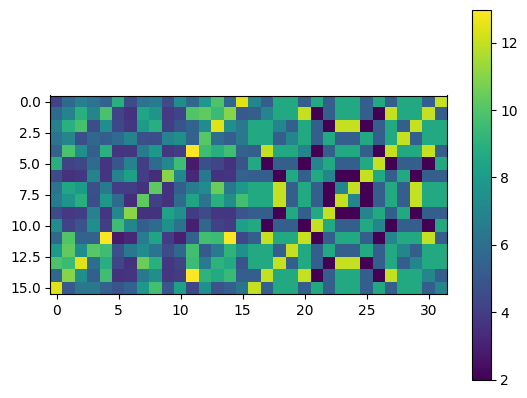

In [ ]:
print('total ',matrix_score_strands(tinystrands,tinytargetG),' ==> mse ', matrix_score_strands(tinystrands,tinytargetG)/16/16)
tinyGdesigned=np.array(binding_matrix(tinystrands))
plt.imshow(np.concatenate([-tinyGdesigned,-np.array(tinytargetG)],axis=1))
plt.colorbar()

In [ ]:
strands=random_strands(32,10) # 32 sticky ends of length 10
tinytargetGdual=dual_rail_targetG(tinyweights,strongestG=-12.0,weakestG=-2.0)
strands=minimize_matrix_imperfection(strands,50000,1,tinytargetGdual, avoid=['GGGG','SSSSS','WWWWWW']) # about 60 min
tinystrandsdual=strands

step 1: score=124360.08251158416
step 3: score=123985.09906494303
step 8: score=122180.59741694728
step 11: score=120866.41809873334
step 15: score=119332.10224607866
step 16: score=105337.07338157715
step 25: score=105170.94549465532
step 26: score=104212.70170022847
step 33: score=104190.46500410064
step 35: score=102962.04430962245
step 40: score=101967.52721960476
step 43: score=87586.39081014566
step 44: score=85898.39894786343
step 46: score=85755.46813991186
step 47: score=72914.12562092236
step 50: score=60262.36607101124
step 51: score=59760.010081465676
step 52: score=59719.07094370705
step 54: score=59678.12401662569
step 57: score=58815.047589471156
step 59: score=58434.67150197584
step 60: score=58112.48434996459
step 69: score=58105.09815865844
step 79: score=57662.786067565714
step 85: score=56939.63367322704
step 89: score=56889.78544063663
step 95: score=56267.507092550724
step 96: score=56240.82363667251
step 97: score=55745.09149822698
step 99: score=55512.4092023837

In [ ]:
tinystrandsdual=\
 ['TTTCTTACAA',
 'TGGGATCCGA',
 'AACCTTCGAA',
 'CATATACAGA',
 'TCGGGATCCA',
 'GAGCTTGTTG',
 'TAGTGCTGCT',
 'TCGTTCGAAG',
 'GAACCTTCGA',
 'TAGCTGCACT',
 'ACAAGAGCTT',
 'GGGATCCGAT',
 'ACTATCTGTA',
 'TTCGAAGGAA',
 'AATGGATCCC',
 'GTAAGAAATA',
 'GTCCCCTGGA',
 'TCTCAAGCTC',
 'GCAGCACATG',
 'GGTAACTAAC',
 'AAGCTCTCAA',
 'ACGGATCCTG',
 'CTTTCGAAGG',
 'TGTGCAGCAT',
 'GTGCAGCATA',
 'GGTTCTTCGA',
 'TCCGGATCCC',
 'GCTCTTGAGA',
 'TAGTTTACCT',
 'CAGTGCTGCA',
 'ACTCAAGCTC',
 'CACACCAGGG']

total  2615.8488339309374  ==> mse  2.554539876885681


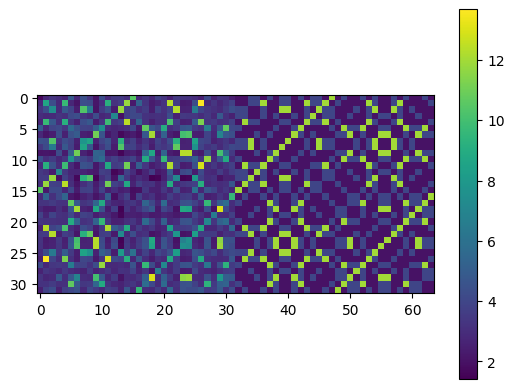

In [ ]:
print('total ',matrix_score_strands(tinystrandsdual,tinytargetGdual),' ==> mse ', matrix_score_strands(tinystrandsdual,tinytargetGdual)/32/32)
tinyGdesigneddual=np.array(binding_matrix(tinystrandsdual))
plt.imshow(np.concatenate([-tinyGdesigneddual,-np.array(tinytargetGdual)],axis=1))
plt.colorbar()

As an imperfect test, we'll locally descend phase energy for present/absent concentrations in two compartments.  We can test both the targetG that we think ought to work, and the designedG that we hope will work.  Maybe neither will work.

In [ ]:
# choose which G we want to evaluate
refG=1.0*np.array(tinyGdesigned)
#refG=1.0*np.array(tinytargetG)

def tinyfFH(phi01):
  N=len(phi01)
  tot=sum(phi01)
  phi=[phi01[i]/tot for i in range(N)]
  binding = sum([ refG[i][j] * phi[i] * phi[j] /2 for i in range(N) for j in range(N)])
  entropy = sum([ 0 if phi[i] < 0.000001 else phi[i]*np.log(phi[i]) for i in range(N) ])
  return  binding + entropy

def tinyfINTERFACE(phi01):
  N=len(phi01)
  totA=sum(phi01)
  phiA=[phi01[i]/totA for i in range(N)]
  totB=sum(1-phi01)
  phiB=[(1-phi01[i])/totB for i in range(N)]
  binding = sum([ refG[i][j] * phiA[i] * phiB[j] for i in range(N) for j in range(N)])
  return  binding

phi01=np.array([ random.choice([0,1]) for i in range(32) ])
print('before')
print(phi01)
print(1-phi01)
laststep=0
for step in range(10000):
  i=random.randint(1,len(phi01))-1
  # newphi01 = np.array([ phi01[j] if not j==i else 1-phi01[j] for j in range(32) ]) # test binary inclusion
  newphi01 = np.array([ phi01[j] if not j==i else random.choice([0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1]) for j in range(32) ]) # test yield of phase separation
  if tinyfFH(phi01)+tinyfFH(1-phi01) > tinyfFH(newphi01)+tinyfFH(1-newphi01):
    phi01=newphi01
    laststep=step
print('after step ',laststep)
print(phi01,' ',tinyfFH(phi01))
print(1-phi01,' ',tinyfFH(1-phi01))
print('interface: ',tinyfINTERFACE(phi01))
phi01=np.array([int(v) for v in list(np.round(phi01))])
print(phi01,' ',tinyfFH(phi01))
print(1-phi01,' ',tinyfFH(1-phi01))
print('interface: ',tinyfINTERFACE(phi01))
print(all(phi01[:16]==phi01[-16:]))

print([ all(phi01[:16]==tinypats01[i]) for i in range(3) ] + [ all(phi01[:16]==1-tinypats01[i]) for i in range(3) ])
print([ all(phi01[-16:]==tinypats01[i]) for i in range(3) ] + [ all(phi01[-16:]==1-tinypats01[i]) for i in range(3) ])

before
[1 0 1 1 1 0 1 0 1 0 1 1 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1 0 0]
[0 1 0 0 0 1 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 1]
after step  1963
[0.9 1.  1.  0.9 1.  0.1 0.1 1.  1.  0.1 0.2 1.  0.9 1.  1.  0.9 0.9 0.2
 0.1 0.9 0.1 1.  1.  0.1 0.2 1.  1.  0.1 0.9 0.1 0.1 0.9]   -6.231407000451654
[0.1 0.  0.  0.1 0.  0.9 0.9 0.  0.  0.9 0.8 0.  0.1 0.  0.  0.1 0.1 0.8
 0.9 0.1 0.9 0.  0.  0.9 0.8 0.  0.  0.9 0.1 0.9 0.9 0.1]   -7.037770472407928
interface:  -4.221648299977962
[1 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 1 0 0 1]   -6.143128286340769
[0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 0 1 1 0]   -7.02973276847745
interface:  -3.832148887434352
False
[True, False, False, False, False, False]
[False, True, False, False, False, False]


In [ ]:
tinystrandsV3=tinystrands
tinystrandsV3

['TTCAAGCGGG',
 'GATTCAAGAA',
 'GAAGCTTGAA',
 'TCTTGGTGGT',
 'CAAGATTCAA',
 'CCCGGTGTAT',
 'CCACCGGGGG',
 'GCTTGAATCT',
 'AGCTTGAATC',
 'ACCGGGGGTA',
 'TATACCCGGT',
 'TGAATCAAGC',
 'CCCCCTTGAA',
 'TTGAAGCTTG',
 'TGATTCAAGA',
 'CGGGCAAGCA',
 'TGAATCCCCC',
 'TACACCCGGT',
 'ACCGGGGGTA',
 'ACAAGCGGGT',
 'CCCGGTGTAT',
 'GAATCAAGCA',
 'GAAGCTTGAA',
 'TACCACCGGG',
 'ACCGGGGGGA',
 'GAAGCTTGAA',
 'CAAGGATTCA',
 'TATACCCCGG',
 'CGGGAGCTTC',
 'ACCACCGGGG',
 'ACCCGGTGTA',
 'CTCCCCCTTG']

In [ ]:
tinystrandsV2=tinystrands
tinystrandsV2

['CGGGGGTCGT',
 'ATGCAGGCGC',
 'TACGCCGCGT',
 'TGAGACTGCC',
 'TGCGCGGCAG',
 'GGACCCCAAA',
 'GGGTCTCAAT',
 'CGCGCCGTGC',
 'CTGCGCGTGC',
 'TATTGGGAGT',
 'GGGACCCCAA',
 'TGCGGCAGCG',
 'GACTGCCGAG',
 'TACGCCGCGT',
 'GCGCGGCAGC',
 'ACACGGGGTC',
 'GCCTGAGACT',
 'AAGGGGACCC',
 'GAGGGTCTCC',
 'GGTCACGGGG',
 'TGGGACCCCA',
 'GCGGCAGCGT',
 'TACGCGCCGT',
 'GGGTCTCAAT',
 'GTCCCAGTCT',
 'ACGCGCCGTG',
 'CGCGGCAGCA',
 'TTTGGGACCC',
 'GGGGTCACGG',
 'ATTGGGAGTC',
 'GGGACCCCAA',
 'ACTGCTGACC']

In [ ]:
tinystrandsV1=tinystrands
tinystrandsV1

['AATCCCCACA',
 'AAGGCCGCCC',
 'GGGGGGCCCT',
 'AGTGGGTGGG',
 'GCCCGGCCCC',
 'GAATGTGTAC',
 'CACAGTACAC',
 'AGGGGGGCCC',
 'AGGGGGGCCC',
 'TTGTACACAC',
 'ATTCATGTGT',
 'AGGCCGCCCC',
 'TGTGGGTGGG',
 'AGGGGGGCCT',
 'CGGCCCGCCC',
 'CCCCCATTCA',
 'CGGGTGTGTA',
 'GTGTCATGTG',
 'TTGTACACAC',
 'ACACATCCCC',
 'GAATGTGTGA',
 'GCCCGGCCCC',
 'GGGGGCTAGA',
 'GTACACACAC',
 'ACACATGTAC',
 'GGGGCTAGGC',
 'AGGCCGCCCC',
 'TGTGTGAATG',
 'CACATCCCCC',
 'GTACACACAC',
 'TGAATGTGTG',
 'CGGGTGTGCG']

Observations.

It sort of worked.

V1 seemed to phase separate, but only in one way.  That one way did not respect the intended dual-rail representation.

V2 got phase separation in two ways, with overlapping membership. We were aiming for three ways, but the third "memory" never appeared.  Further, the dual-rail representation was not respected.  Room for improvement, but it might already be interesting enough for experimental examination.

V3 attempted to bump up the on-target G from -10 kcal/mol to -12 kcal/mol (after aiming for -15 kcal/mol and longer sticky ends failed) but its performance was not impressive.

All three designs suffered from their being no SSM or WS/PP-repreat prevention -- we likely wouldn't want to actually try these sticky ends.

A further caveat on this code is code is that the "phase separation" modeling is crude, based on a two-compartment assumption.  That is, it assumes that the interactions are strong enough overall that not much material is left in solution, thus whatever is not in compartment 1 is in compartment 2.  Material transfer is in discrete 10% steps, i.e. we assume phase separation forces must be "obvious" and "strong".  Finally, we don't test whether either compartment would spontaneously undergo further spinoidal decomposition.  

It is also concerning that the phase energy densities here end up being closer to -6 kcal / mol (relative to the -2 kcal/mol or so for non-interacting strands) rather than the -8 kcal/mol to -10 kcal/mol for the orthogonal systems used in experiments.

#### 3x3 images might be more feasible experimentally and allow for more accurate sticky end binding matrices

In [ ]:
# Lulu's L and T plus the Game of Life R-pentomino
nanopats01=[ [1,0,0,1,0,0,1,1,1], [1,1,1,0,1,0,0,1,0], [0,1,1,1,0,1,0,0,1]]

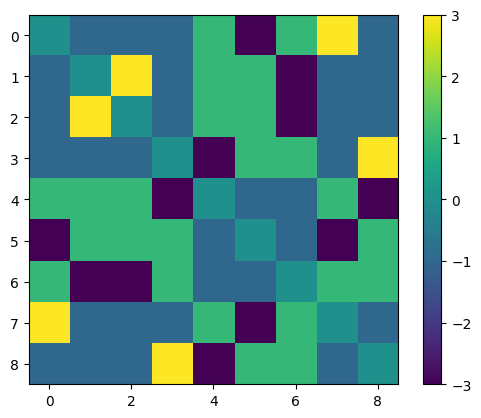

In [ ]:
# Hebbian weights for spin network
nanopats=[ [ 2*v-1 for v in pat] for pat in nanopats01 ]
nanoweights=[[0 for i in range(9)] for j in range(9)]
for vector in nanopats:
  for i in range(9):
    for j in range(9):
      nanoweights[i][j] += 0 if i==j else vector[i]*vector[j]
plt.imshow(nanoweights)
plt.colorbar()

In [ ]:
# this works pretty well
x=np.array([random.choice([-1,+1]) for i in range(9)])
#x=np.array(nanopats[0])
print(x)
while not all(np.sign(nanoweights @ x)==x):
  i=random.randint(1,len(x))-1
  x[i]=np.sign(nanoweights[i] @ x)
print(x)
[ all(x==nanopats[i]) for i in range(3) ] + [ all(-x==nanopats[i]) for i in range(3) ]

[ 1  1  1  1 -1  1  1  1 -1]
[ 1 -1 -1  1 -1 -1  1  1  1]


[True, False, False, False, False, False]

In [ ]:
# weights from -3 to 0 to +3 should correspond to binding strengths -2 to -7 to -12
strands=random_strands(9,10) # 9 sticky ends of length 10
nanotargetG=[ [ -7.0-5.0*nanoweights[i][j]/3.0 for i in range(9)] for j in range(9) ]
strands=minimize_matrix_imperfection(strands,50000,1,nanotargetG, avoid=['GGGG','SSSSS','WWWWWW']) # about 10 min
nanostrands=strands

In [ ]:
nanostrands=\
 ['GAGGCACCAA',
 'TCGAGCGAAG',
 'ACTGAGCTCG',
 'CGACGCAGCA',
 'GGTTAGGCTC',
 'CGAGTCGCAG',
 'CCTGGTGACG',
 'TGCCTCACCG',
 'GCTGCACGTC']

total  218.0290086830766  ==> mse  2.6917161565811925


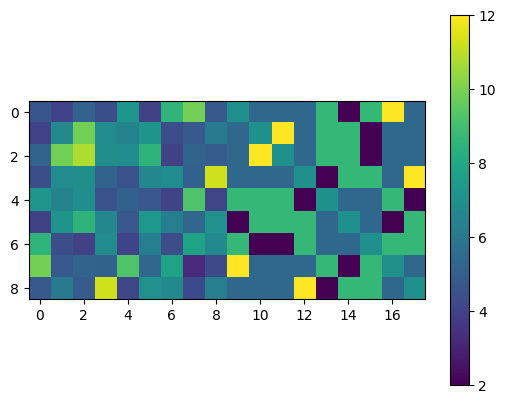

In [ ]:
print('total ',matrix_score_strands(nanostrands,nanotargetG),' ==> mse ', matrix_score_strands(nanostrands,nanotargetG)/9/9)
nanoGdesigned=np.array(binding_matrix(nanostrands))
plt.imshow(np.concatenate([-nanoGdesigned,-np.array(nanotargetG)],axis=1))
plt.colorbar()

In [ ]:
# is it easier to design weights that are less graded?
strands=random_strands(18,10) # 18 sticky ends of length 10
nanotargetGdual=dual_rail_targetG(nanoweights,strongestG=-12.0,weakestG=-2.0)
strands=minimize_matrix_imperfection(strands,50000,1,nanotargetGdual, avoid=['GGGG','SSSSS','WWWWWW']) # about 10 min
nanostrandsdual=strands

In [ ]:
nanostrandsdual=\
 ['CCAACGGTAG',
 'TGTAATGTTT',
 'TGTAAAACAT',
 'CTATTAGGCT',
 'GTGTTCACAC',
 'GATTTGATGC',
 'CAGCTCCCTG',
 'CGACTACCAA',
 'TAGAGGCTAA',
 'GCATCAAATG',
 'GGGAGCTGCC',
 'GGGAGCTACC',
 'GAACACACAC',
 'TTTAGCCTAA',
 'CCGTTGGTAG',
 'GTTTTACATT',
 'GATGCAATCT',
 'CAAGTGTGTG']

total  823.7156951460338  ==> mse  2.5423323924260304


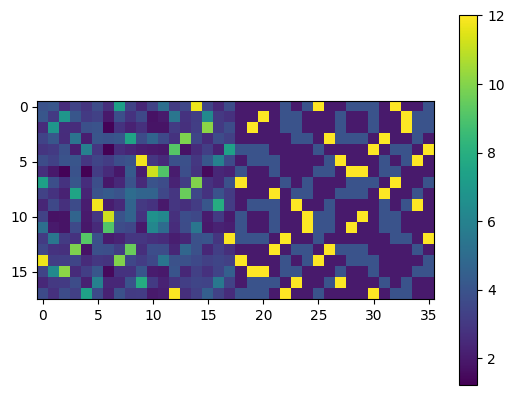

In [ ]:
print('total ',matrix_score_strands(nanostrandsdual,nanotargetGdual),' ==> mse ', matrix_score_strands(nanostrandsdual,nanotargetGdual)/18/18)
nanoGdesigneddual=np.array(binding_matrix(nanostrandsdual))
plt.imshow(np.concatenate([-nanoGdesigneddual,-np.array(nanotargetGdual)],axis=1))
plt.colorbar()

# Evaluating DNA nanostar sticky-end designs per Flory-Huggins phase separation



Given a target delta-G matrix, or a ViennaRNA-predicted interaction matrix, does Flory-Huggins predict phase separation into the target phases?

The Flory-Huggins energy density, in units of $R T / L$, is

$$\frac{f_{FH}}{c_0 R T} = \tilde{f}_{FH} = \frac{1}{2} \sum_{i,j} X_{i,j} \phi_i \phi_j + \sum_i \phi_i \ln \phi_i$$
where
$$X_{i,j} = \frac{z}{2 R T} ( 2 \Delta G_{i,j} - \Delta G_{i,i} - \Delta G_{j,j} )$$

and $\phi_i$ is the volume fraction of species $i$.  Here, we think of $\Delta G_{i,j}$ being the energy of molecules of type $i$ next to molecules of type $j$, while $z$ is the coordination number indicating how many interactions each molecules has.  A constant concentration (density) of molecules $c_0$ is assumed, and we assume dynamics will conserve the total concentration of each species among multiple compartments.

Thus, if we consider the energy density of DNA nanostars that have sticky ends with binding energies $\Delta G_{i,j}$ and a per-nanostar "distortion and entropy loss" penalty $\Delta G_i$ for species $i$ being in the liquid phase, then we get the per-mole-of-molecule average energy for a well-mixed phase

$$ g_{FH} = c_0 R T \left[ \sum_i \phi_i \ln \phi_i \right] + c_0 \left[ \sum_{i,j} \frac{z}{2} \Delta G_{i,j} \phi_i \phi_j + \sum_i \Delta G_i \phi_i \right] $$

which can be related to the standard Flory-Huggins by noting that, although the offsets that normalize $X_{i,j}$ to have a zero diagonal give rise to differences between $f_{FH}$ and $g_{FH}$ that depend on the phase composition $\phi$, these differences are irrelevant when considering an entire multicompartment system where to total amount of each species is preserved.  In that case, for volume $V^\alpha$ for compartment $\alpha$ with phase composition $\phi^\alpha$, we have

$$ \sum_\alpha V^\alpha f_{FH}(\phi^\alpha) = \sum_\alpha V^\alpha g_{FH}(\phi^\alpha) + \left[ constant \right] $$

The bottom line is that for our multicomponent phase separation analysis below, we could use $\tilde{f}_{FH}$ as above, with $X_{i,j}$ computed from the estimated ViennaRNA-predicted binding energies, $z=4$.  However, there would be no harm in using $\tilde{g}_{FH} = \frac{g_{FH}}{c_0 R T}$ with not-necessarily-zero-diagonal binding matrix $\frac{z \Delta G_{i,j}}{R T}$ instead of $X_{i,j}$ and using $\Delta G_i = 0$.  So that is what we will do.

Note, however, that Olivia finds that the densities of her DNA nanostars are not constant; in fact, they can vary by a factor of 2 depending on the sticky end binding energy.  Additionally, I haven't thought through how best to treat a "solvent species" as it would have a different "density" and thus baseline "concentration".  For this section we will proceed by acknowledging but ignoring these caveats, and treating only the phase separation behavior of condensed nanostars, and not asking how strong the interactions have to be in order for condensation to occur.



In [ ]:
def flory_huggins(volumes, X):
  """total energy, i.e. flory-huggins density * total volume, for given volumes of species, assuming well-mixed"""
  N = len(X)
  vol = sum(volumes)
  phi = np.array(volumes)/vol
  interaction = 0.5 * sum([ X[i][j] * phi[i] * phi[j] for i in range(N) for j in range(N) ])
  entropy = sum([ 0 if phi[i]<0.00000001 else phi[i] * np.log(phi[i]) for i in range(N) ])
  return vol * (interaction + entropy)

def total_flory_huggins(components, X):
  return sum([flory_huggins(component,X) for component in components])

def merge_split_phases(compartments, X, steps=100, fudge=0.001, printout=True):
  # fudge factor allows merges and transfers that are a tiny bit unfavorable
  N = len(X)
  comps = [ np.array(comp) for comp in compartments ]
  energy=total_flory_huggins(comps,X)
  totvol=np.sum(comps)
  if printout:
    print(f'starting energy density: {energy/totvol} for {len(comps)} compartments')
  amounts=[ sum([comps[n][i] for n in range(len(comps))]) for i in range(N) ]

  for step in range(steps):
    action = 'merge' if step==steps-1 else random.choices(['merge','split','transfer'],weights=[0.01,0.1,1])[0]
    #action = random.choices(['merge','split','transfer'],weights=[0.01,0.1,1])[0]

    if action=='merge': # keep merging until no more merging is possible
      done=False
      while len(comps)>1 and not done:
        done=True
        pairs = [ (n,m) for n in range(len(comps)) for m in range(len(comps)) if n<m ]
        for (n,m) in pairs:
          if flory_huggins(comps[n]+comps[m],X) < flory_huggins(comps[n],X)+flory_huggins(comps[m],X) + fudge*abs(energy):
             comps = [ comps[l] for l in range(len(comps)) if not l in [n,m] ] + [ comps[n]+comps[m] ]
             energy=sum([flory_huggins(comps[n],X) for n in range(len(comps))])
             #print(f'merge step {step} energy: {sum([flory_huggins(comps[n],X) for n in range(len(comps))])/totvol} for {len(comps)} compartments')
             done=False
             break

    if action=='split': # split one randomly-chosen compartment with no transfer
      n = random.choice(range(len(comps)))
      s = random.random()
      comps = [ comps[l] for l in range(len(comps)) if not l in [n] ] + [ s*comps[n], (1-s)*comps[n] ]

    if action=='transfer' and len(comps)>1: # attempt transfer of one species between randomly chosen compartments
      (n,m) = random.sample(range(len(comps)),2)
      i = random.choice(range(N))
      s = random.random()
      delta = np.array([ 0 if not j==i else s * comps[n][i] for j in range(N) ])
      if flory_huggins(comps[n]-delta,X)+flory_huggins(comps[m]+delta,X) < flory_huggins(comps[n],X)+flory_huggins(comps[m],X) + fudge*abs(energy):
         comps = [ comps[l] for l in range(len(comps)) if not l in [n,m] ] + [ comps[n]-delta, comps[m]+delta ]
         energy=sum([flory_huggins(comps[n],X) for n in range(len(comps))])
         #print(f'transfer step {step} energy: {sum([flory_huggins(comps[n],X) for n in range(len(comps))])/totvol} for {len(comps)} compartments')

  if printout:
    print(f'final energy density: {energy/totvol} for {len(comps)} compartments')
  newamounts=[ sum([comps[n][i] for n in range(len(comps))]) for i in range(N) ]
  if max(np.abs(np.array(newamounts)-np.array(amounts))) > max(amounts)/100000:
    print(" amounts changed by ", np.array(newamounts)-np.array(amounts))

  return comps

def sorted_components(components):
  binned = [ int("".join(str(i) for i in [0+(v > max(vals)/2) for v in vals]),2) for vals in components ]
  indexorder = np.argsort(binned)
  return [ components[i] for i in indexorder ]

In [ ]:
testX=[[0,10,10],[10,0,10],[10,10,0]]
c=merge_split_phases([ [100,100,100] ], testX, 3000)

starting energy density: 2.234721044665223 for 1 compartments
final energy density: -8.549959964552464e-05 for 3 compartments


In [ ]:
c

[array([9.99948678e+01, 3.32130195e-03, 4.78247896e-03]),
 array([2.49759884e-03, 9.99934919e+01, 3.36961892e-03]),
 array([2.63456231e-03, 3.18679191e-03, 9.99918479e+01])]

In [ ]:
# scaling factor for 4-arm nanostars from sticky end binding Gij to Xij at 20 deg C
zRT = 4 / (0.002 * (273.15 + 20))
zRT

6.822445846836091

In [ ]:
# what does it look like for a real system?
testX=zRT*yanchengGdesigned
c=merge_split_phases([ [ 100, 100, 100, 100 ] ], testX, 3000)
c

starting energy density: -15.39169193099793 for 1 compartments
final energy density: -28.973752689013427 for 4 compartments


[array([5.37388954e-05, 3.93895423e-01, 3.82145601e-02, 9.86711992e+01]),
 array([3.37051426e-04, 9.82871925e+01, 5.82740882e-02, 8.97577898e-02]),
 array([9.95998609e+01, 3.33194265e-01, 9.74010551e-03, 9.51333472e-01]),
 array([ 0.3997483 ,  0.98571783, 99.89377125,  0.28770952])]

In [ ]:
smallpats01

[[0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0],
 [1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1],
 [1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1]]

In [ ]:
(np.min(smallweights01), np.max(smallweights01),np.min(smalltargetG01), np.max(smalltargetG01),np.min(smallGdesigned01), np.max(smallGdesigned01))

(0, 3, -17.0, -2.0, -14.241395115852356, -2.5398812294006348)

starting energy density: -26.645722571524026 for 1 compartments
final energy density: -28.266232759248933 for 3 compartments


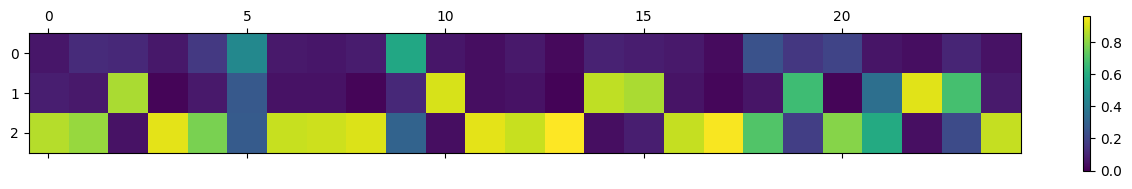

In [ ]:
# for binary Hebbian learning before we get phase separation, but with a very modest change in energy, and just two phases (always same or different splits?)
testX=zRT*np.array(smallGdesigned01)
c=merge_split_phases([ [1 for i in range(25)] ], testX, 5000)
plt.matshow(c, vmin=0)
plt.colorbar()

starting energy density: -26.645722571524026 for 1 compartments
final energy density: -28.13253205346734 for 2 compartments


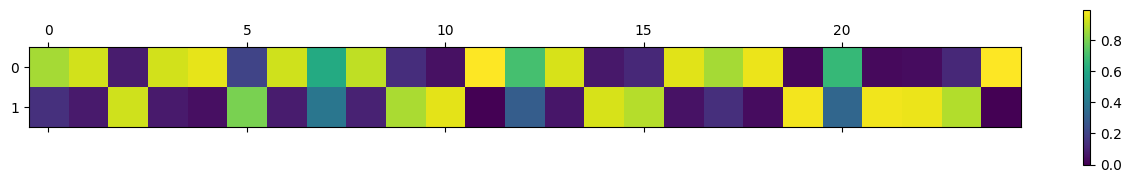

In [ ]:
# for binary Hebbian learning before we get phase separation, but with a very modest change in energy, and just two phases (always same or different splits?)
testX=zRT*np.array(smallGdesigned01)
c=merge_split_phases([ [1 for i in range(25)] ], testX, 5000)
plt.matshow(c, vmin=0)
plt.colorbar()

starting energy density: -25.463557281289457 for 1 compartments
final energy density: -31.212135947377696 for 4 compartments


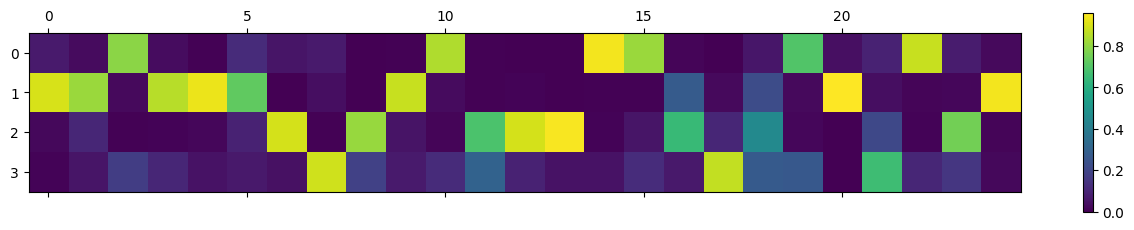

In [ ]:
# The spin weights phase separate without change, and although the final patterns aren't what we want, their average energy density is comparable to experimental systems
testX=zRT*np.array(smallGdesigned)
c=merge_split_phases([ [1 for i in range(25)] ], testX, 5000)
plt.matshow(c, vmin=0)
plt.colorbar()

starting energy density: -26.26972915600646 for 1 compartments
final energy density: -32.34183052819197 for 3 compartments


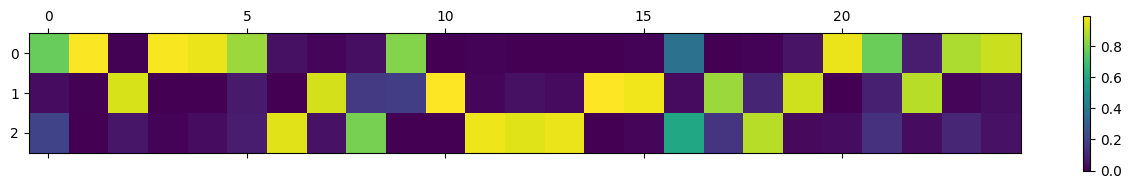

In [ ]:
# The clipped spin weights phase separate similarly
testX=zRT*np.array(smallGdesignedclip)
c=merge_split_phases([ [1 for i in range(25)] ], testX, 5000)
plt.matshow(c, vmin=0)
plt.colorbar()

Don't believe the comments below!  They are out of date!  The designed systems seem to be too strong?  What does it mean to be locally stable?

In [ ]:
# these are the smallest non-clipped and clipped weights for which I saw phase separation into all three phases (or close enough)
#testX = -15*np.array(smallweights)
#testX = -30*np.array(smallweights).clip(-1,+1) # stronger gives clearer phases; phenomena are otherwise generally similar to unclipped matrix
#testX = zRT*np.array(smalltargetG) # unrealistically strong, but doesn't seem to phase separate at lower values
testX = zRT*np.array(smallGdesigned) # splits into many phases with just a few species each
#testX = zRT*np.array(smallGdesigned01) # splits into many phases with just a few species each
testX = zRT*np.array(smallGdesignedclip) # nicely splits into three (or more) phases with just a few species each

# spinoidal decomposition -- could find any number of possible stable stables, but #0 and #1 are most common
c=[ np.array([100 for i in range(25)]) ]
# check stability of equal mixture of all target phases.... they are not stable, and a super-stable weird mixture of 3 phases is sometimes found!
#c=[ 33.33*np.array([ p for p in pat ]) for pat in smallpats01 ] + [ 33.33*np.array([ (1-p) for p in pat ]) for pat in smallpats ]
# check stability of mixture of target pattern #0 -- very stable!
#c=[ 100*np.array([ p for p in pat ]) for pat in smallpats01[0:1] ] + [ 100*np.array([ (1-p) for p in pat ]) for pat in smallpats01[0:1] ]
# check stability of mixture of target pattern #1 -- very stable!
#c=[ 100*np.array([ p for p in pat ]) for pat in smallpats01[1:2] ] + [ 100*np.array([ (1-p) for p in pat ]) for pat in smallpats01[1:2] ]
# check stability of mixture of target pattern #2 -- very stable, but 2% higher phase energy than the other two
#c=[ 100*np.array([ p for p in pat ]) for pat in smallpats01[2:3] ] + [ 100*np.array([ (1-p) for p in pat ]) for pat in smallpats01[2:3] ]
# check what results from 20 random initial patterns with roughly same per-species total as the other initial patterns
#c=[ np.array([ 10*random.random() for _ in range(25) ]) for _ in range(20) ]

steps_per_update=250
for i in range(1000):
  cc=sorted_components(c)
  plt.matshow(np.concatenate([ m.reshape(5,5) for m in cc], axis=1))
  plt.title(f'step {steps_per_update*i}: energy = {total_flory_huggins(c,testX)/np.sum(c):.3f} ({np.min(cc):.1f}/{np.max(cc):.1f})\n'
            f'energies: {[flory_huggins(m,testX)/sum(m) for m in cc]}\n'
            f'volumes: {[sum(m) for m in cc]}')
  display.display(plt.gcf())
  c=merge_split_phases(c, testX, steps_per_update, fudge=0.0001, printout=False)
  display.clear_output(wait=True)
  plt.close()

In [ ]:
testX = zRT*np.array(smallGdesigneddual)
#testX = zRT*np.array(smallGdesignedclipdual)
testX = zRT*np.array(smalltargetGdual)
#testX = zRT*np.array(smalltargetGclipdual)

# spinoidal decomposition -- could find any number of possible stable stables, but #0 and #1 are most common
c=[ np.array([100 for i in range(50)]) ]
# check stability of equal mixture of all target phases.... they are not stable, and a super-stable weird mixture of 3 phases is usually found!
#c=[ 33.33*np.array([ (1+p)/2 for p in pat ]+[ (1-p)/2 for p in pat ]) for pat in smallpats ] + [ 33.33*np.array([ (1-p)/2 for p in pat ]+[ (1+p)/2 for p in pat ]) for pat in smallpats ]
# check stability of mixture of target pattern #0 -- very stable!
c=[ 100*np.array([ (1+p)/2 for p in pat ]+[ (1-p)/2 for p in pat ]) for pat in smallpats[0:1] ] + [ 100*np.array([ (1-p)/2 for p in pat ]+[ (1+p)/2 for p in pat ]) for pat in smallpats[0:1] ]
# check stability of mixture of target pattern #1 -- very stable!
#c=[ 100*np.array([ (1+p)/2 for p in pat ]+[ (1-p)/2 for p in pat ]) for pat in smallpats[1:2] ] + [ 100*np.array([ (1-p)/2 for p in pat ]+[ (1+p)/2 for p in pat ]) for pat in smallpats[1:2] ]
# check stability of mixture of target pattern #2 -- somewhat stable, but not perfectly so...
#c=[ 100*np.array([ (1+p)/2 for p in pat ]+[ (1-p)/2 for p in pat ]) for pat in smallpats[2:3] ] + [ 100*np.array([ (1-p)/2 for p in pat ]+[ (1+p)/2 for p in pat ]) for pat in smallpats[2:3] ]
# check what results from 200 random initial patterns with roughly same per-species total as the other initial patterns
#c=[ np.array([ random.random() for _ in range(50) ]) for _ in range(200) ]
# how do pure phases combine?
#c=[ np.array([ 100*(i==j) for j in range(50) ]) for i in range(50) ]


steps_per_update=250
for i in range(1000):
  cc=sorted_components(c)
  plt.matshow(np.concatenate([ m.reshape(10,5) for m in cc], axis=1))
  plt.title(f'step {steps_per_update*i}: energy = {total_flory_huggins(c,testX)/np.sum(c):.3f} ({np.min(cc):.1f}/{np.max(cc):.1f})\n'
            f'energies: {[flory_huggins(m,testX)/sum(m) for m in cc]}\n'
            f'volumes: {[sum(m) for m in cc]}')
  display.display(plt.gcf())
  c=merge_split_phases(c, testX, steps_per_update, fudge=0.0001, printout=False)
  display.clear_output(wait=True)
  plt.close()

In [ ]:
def binary_merge_split_phases(components, X, steps):
  c=components
  N=len(components[0])
  tots=[ sum([c[k][i] for k in range(len(c))]) for i in range(N)]
  b=[ [ m[i]>0 for m in c ].index(1) for i in range(N) ] # we will have each species in exactly 1 compartment, all of it.  b says which.
  for _ in range(steps):
    if random.random()<0.9: # one species moves
      i=random.randint(0,N-1)
      bb=[ random.choice(list(set(b))) if j==i else b[j] for j in range(N) ]
    elif random.random()<0.5: # two compartments merge
      old=random.choice(list(set(b)))
      new=random.choice(list(set(b)))
      bb=[ b[j] if not b[j] in [old,new] else new for j in range(N) ]
    else: # one compartment splits
      old=random.choice(list(set(b)))
      new=max(b)+1
      bb=[ b[j] if not b[j]==old else random.choice([old,new]) for j in range(N) ]
    if not len(set(b))==max(b)+1: # get rid of an empty compartment
      new=min([k for k in range(max(b)+1) if not k in b])
      old=max(b)
      bb=[ b[j] if not b[j]==old else new for j in range(N) ]
    cc=[ np.array([tots[j] if bb[j]==k else 0 for j in range(N)]) for k in range(1+np.max(bb))]
    if total_flory_huggins(cc,X) < total_flory_huggins(c,X):
      (c,b)=(cc,bb)
  return c

In [ ]:
#testX = zRT*np.array(smalltargetG) # unrealistically strong, but doesn't seem to phase separate at lower values
#testX = zRT*np.array(smalltargetGclip)
#testX = zRT*np.array(smallGdesigned) # splits into many phases with just a few species each
#testX = zRT*np.array(smallGdesigned01) # splits into many phases with just a few species each
testX = zRT*np.array(smallGdesignedclip) # nicely splits into three (or more) phases with just a few species each

# spinoidal decomposition -- could find any number of possible stable stables, but #0 and #1 are most common
c=[ np.array([100 for i in range(25)]) ]
# check stability of mixture of target pattern #0 -- very stable!
#c=[ 100*np.array([ p for p in pat ]) for pat in smallpats01[0:1] ] + [ 100*np.array([ (1-p) for p in pat ]) for pat in smallpats01[0:1] ]
# check stability of mixture of target pattern #1 -- very stable!
#c=[ 100*np.array([ p for p in pat ]) for pat in smallpats01[1:2] ] + [ 100*np.array([ (1-p) for p in pat ]) for pat in smallpats01[1:2] ]
# check stability of mixture of target pattern #2 -- very stable, but 2% higher phase energy than the other two
#c=[ 100*np.array([ p for p in pat ]) for pat in smallpats01[2:3] ] + [ 100*np.array([ (1-p) for p in pat ]) for pat in smallpats01[2:3] ]
# how do pure phases combine?
#c=[ np.array([ 100*(i==j) for j in range(25) ]) for i in range(25) ]

steps_per_update=250
for i in range(1000):
  cc=sorted_components(c)
  plt.matshow(np.concatenate([ m.reshape(5,5) for m in cc], axis=1))
  plt.title(f'step {steps_per_update*i}: energy = {total_flory_huggins(c,testX)/np.sum(c):.3f} ({np.min(cc):.1f}/{np.max(cc):.1f})\n'
            f'energies: {[flory_huggins(m,testX)/sum(m) for m in cc]}\n'
            f'volumes: {[sum(m) for m in cc]}')
  display.display(plt.gcf())
  c=binary_merge_split_phases(c, testX, steps_per_update)
  display.clear_output(wait=True)
  plt.close()

In [ ]:
testX = zRT*np.array(smallGdesigneddual)
#testX = zRT*np.array(smallGdesignedclipdual)
#testX = zRT*np.array(smalltargetGdual)
#testX = zRT*np.array(smalltargetGclipdual)

# spinoidal decomposition -- could find any number of possible stable stables, but #0 and #1 are most common
c=[ np.array([100 for i in range(50)]) ]
# check stability of mixture of target pattern #0 -- very stable!
c=[ 100*np.array([ p for p in pat ]+[ 1-p for p in pat ]) for pat in smallpats01[0:1] ] + [ 100*np.array([ 1-p for p in pat ]+[ p for p in pat ]) for pat in smallpats01[0:1] ]
# check stability of mixture of target pattern #1 -- very stable!
#c=[ 100*np.array([ p for p in pat ]+[ 1-p for p in pat ]) for pat in smallpats01[1:2] ] + [ 100*np.array([ 1-p for p in pat ]+[ p for p in pat ]) for pat in smallpats01[1:2] ]
# check stability of mixture of target pattern #2 -- somewhat stable, but not perfectly so...
#c=[ 100*np.array([ p for p in pat ]+[ 1-p for p in pat ]) for pat in smallpats01[2:3] ] + [ 100*np.array([ 1-p for p in pat ]+[ p for p in pat ]) for pat in smallpats01[2:3] ]
# how do pure phases combine?
#c=[ np.array([ 100*(i==j) for j in range(50) ]) for i in range(50) ]

steps_per_update=250
for i in range(1000):
  cc=sorted_components(c)
  plt.matshow(np.concatenate([ m.reshape(10,5) for m in cc], axis=1))
  plt.title(f'step {steps_per_update*i}: energy = {total_flory_huggins(c,testX)/np.sum(c):.3f} ({np.min(cc):.1f}/{np.max(cc):.1f})\n'
            f'energies: {[flory_huggins(m,testX)/sum(m) for m in cc]}\n'
            f'volumes: {[sum(m) for m in cc]}')
  display.display(plt.gcf())
  c=binary_merge_split_phases(c, testX, steps_per_update)
  display.clear_output(wait=True)
  plt.close()

starting energy density: -3.241338722239781 for 1 compartments
final energy density: -7.714839131136073 for 3 compartments


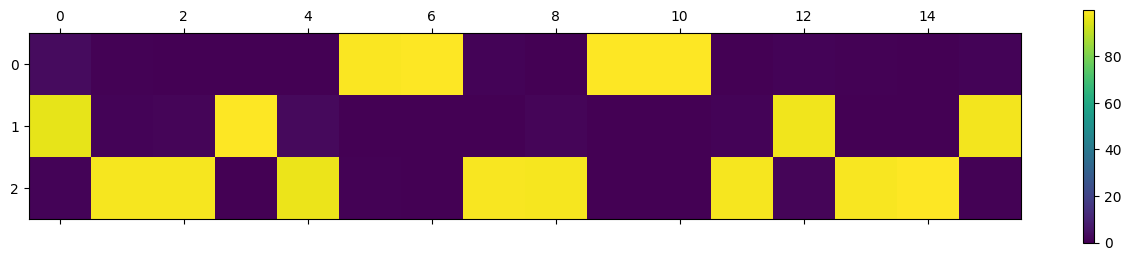

In [ ]:
testX=-15*np.array(tinyweights)
c=merge_split_phases([ [100 for i in range(16)] ], testX, 5000)
plt.matshow(c, vmin=0)
plt.colorbar()

starting energy density: -8.153235902799725 for 1 compartments
final energy density: -9.920203811407271 for 2 compartments


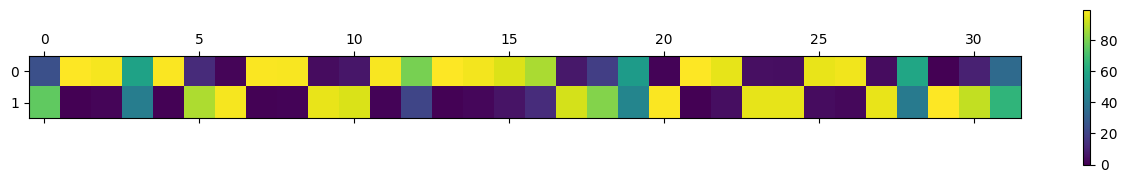

In [ ]:
testX = 2*np.array(tinytargetG)
c=merge_split_phases([ [100 for i in range(32)] ], testX, 5000)
plt.matshow(c, vmin=0)
plt.colorbar()

In [ ]:
tinypats

array([[ 1,  1,  1,  1,  1, -1, -1,  1,  1, -1, -1,  1,  1,  1,  1,  1],
       [ 1, -1, -1,  1, -1,  1,  1, -1, -1,  1,  1, -1,  1, -1, -1,  1],
       [ 1, -1,  1, -1, -1,  1, -1,  1,  1, -1,  1, -1, -1,  1, -1,  1]])

In [ ]:
tinyGdesigned

NameError: ignored

In [ ]:
testX = 2*np.array(tinytargetG)
testX = 2*np.array(tinytargetG)
testX = 2*np.array(tinytargetG)
# spinoidal decomposition -- could find any number of possible stable stables, but #0 and #1 are most common
c=[ np.array([100 for i in range(32)]) ]
# check stability of equal mixture of all target phases.... they are not stable, and a super-stable weird mixture of 3 phases is usually found!
#c=[ 33.33*np.array([ (1+p)/2 for p in pat ]+[ (1-p)/2 for p in pat ]) for pat in tinypats ] + [ 33.33*np.array([ (1-p)/2 for p in pat ]+[ (1+p)/2 for p in pat ]) for pat in tinypats ]
# check stability of mixture of target pattern #0 -- very stable!
#c=[ 100*np.array([ (1+p)/2 for p in pat ]+[ (1-p)/2 for p in pat ]) for pat in tinypats[0:1] ] + [ 100*np.array([ (1-p)/2 for p in pat ]+[ (1+p)/2 for p in pat ]) for pat in tinypats[0:1] ]
# check stability of mixture of target pattern #1 -- very stable!
#c=[ 100*np.array([ (1+p)/2 for p in pat ]+[ (1-p)/2 for p in pat ]) for pat in tinypats[1:2] ] + [ 100*np.array([ (1-p)/2 for p in pat ]+[ (1+p)/2 for p in pat ]) for pat in tinypats[1:2] ]
# check stability of mixture of target pattern #2 -- somewhat stable, but not perfectly so...
#c=[ 100*np.array([ (1+p)/2 for p in pat ]+[ (1-p)/2 for p in pat ]) for pat in tinypats[2:3] ] + [ 100*np.array([ (1-p)/2 for p in pat ]+[ (1+p)/2 for p in pat ]) for pat in tinypats[2:3] ]
# check what results from 200 random initial patterns with roughly same per-species total as the other initial patterns
#c=[ np.array([ random.random() for _ in range(32) ]) for _ in range(200) ]

steps_per_update=250
for i in range(1000):
  cc=sorted_components(c)
  plt.matshow(np.concatenate([ m.reshape(8,4) for m in cc], axis=1))
  plt.title(f'step {steps_per_update*i}: energy = {total_flory_huggins(c,testX):.1f} ({np.min(cc):.1f}/{np.max(cc):.1f})')
  display.display(plt.gcf())
  c=merge_split_phases(c, testX, steps_per_update, printout=False)
  display.clear_output(wait=True)
  plt.close()

starting energy: -25856.07739029083 for 2 compartments
final energy: -28845.26175893859 for 2 compartments


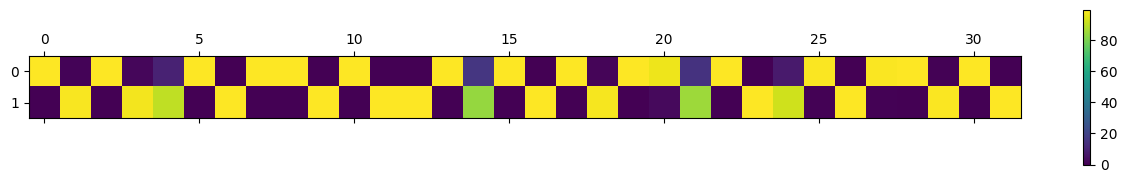

In [ ]:
testX = 2*np.array(tinytargetG)
c=merge_split_phases([ [0,0,0,0,0]+[50 for i in range(27)], [100,100,100,100,100]+[50 for i in range(27)] ], testX, 10000)
plt.matshow(c, vmin=0)
plt.colorbar()

# Design based on phase separation